In [ ]:
import  sklearn
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd
import warnings
from sklearn import preprocessing
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import shap
import copy
import matplotlib.pyplot as plt
from lightgbm import LGBMRegressor
from sklearn import datasets
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import time
import lightgbm as lgb
from sklearn.model_selection import KFold
import torch
import torch.optim as optim
from sklearn.ensemble import RandomForestRegressor
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import copy
import numpy as np
from xgboost import DMatrix, train
from sklearn.datasets import make_regression
import torch.optim as optim
np.random.seed(42)
torch.manual_seed(42)
warnings.filterwarnings("ignore")
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import matplotlib
import pickle
import glob
import numpy as np
from scipy.stats import *
import xgboost as xgb
import torch.nn.functional as F
import numpy as np
from scipy.stats import mode
import copy
from torch.utils.data import Dataset, DataLoader
import torch
import os

matplotlib.rcParams['font.sans-serif'] = ['SimHei']  
matplotlib.rcParams['axes.unicode_minus'] = False 

def set_seed(seed):
    import random
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed(42)



"""---------global variables------"""
train_data,val_data,test_data,train_labels,val_labels,test_labels=None,None,None,None,None,None
test_DEM,test_HRDEM,test_FABDEM,test_FathomDEM,test_Pid,test_GEDTM30=None,None,None,None,None,None

train_loader,val_loader,test_loader=None,None,None
featureNum,landformArray=None,None


AllTrainingFatures = [
    "IDW", "Lon", "Lat", "LandCover", "ForestCoverage", "ForestHeight", "ForestHeight10", "ForestHeight30",
    "BuildingHeight90", "Pop", "NightLight", "Aspect", "Hillshade", "Curvature", "ProfileCur", "PlanCur", 
    "DEM", "STDDEM", "Max_MinDEM", "Mean_MinDEM", "deltMeanDEM", "deltMedianDEM", "deltMinDEM", "deltMaxDEM",
    "Slope", "MaxSlope", "STDSlope", "Mean_MinSlope", "Max_MinSlope", "deltMeanSlope", "SOS", "SOA","HEL","FCLoss","FCGain","NIR","RGB","SAR_VV","SAR_VH"
]




def genTrainingData_HRDEM(numpy_data,cols_names,selected_features,mean_std_path, IsEmpty=True):
    trainingdata_num=numpy_data.shape[0]

    data_reshaped = numpy_data.reshape(-1, numpy_data.shape[1]*numpy_data.shape[2], numpy_data.shape[3])  
    data_final_2d = data_reshaped.reshape(-1, numpy_data.shape[3]) 
  
    df = pd.DataFrame(data_final_2d, columns=cols_names)

    df['DEM_HR'] = df['DEM'] - df['HRDEM'] 
    

    if IsEmpty:
    
        df.loc[df['LandCover'].isin([187,210,0]), "Pid"] = -1  #xxx

        df.loc[(df['DEM_HR'] < -200) | (df['DEM_HR'] > 200), "Pid"] = -1     #xxx

        df.loc[df['Pid'] == -1, :] = np.nan


    HRDEMArray = np.array(df['HRDEM'])
    df = df.drop('HRDEM', axis=1)

    labelArray = np.array(df['DEM_HR'])
    df = df.drop('DEM_HR', axis=1)


    PidArray = np.array(df['Pid'])
    df = df.drop('Pid', axis=1)

   

    """ Forest canopy height (0-60 heights 101 water  102 snow/ice  103 Nodata) """
    if 'ForestHeight30' in df.columns.tolist():
        df.loc[(df['ForestHeight30'] > 100) | (df['ForestHeight30'] < 0), 'ForestHeight30'] = 0


    FABDEMArray = np.array(df['FABDEM'])
    df = df.drop('FABDEM', axis=1)

    GEDTM30Array = np.array(df['GEDTM30'])*10
    df = df.drop('GEDTM30', axis=1)

    FathomDEMArray = np.array(df['FathomDEM'])
    df = df.drop('FathomDEM', axis=1)

    DEMArray = np.array(df['DEM'])

 
    df=df[selected_features]
    features = np.array(df)


    selected_indices = [AllTrainingFatures.index(feat) for feat in selected_features]

    mean_val_all=np.load(mean_std_path)['mean'] 
    std_val_all=np.load(mean_std_path)['std']
    mean_val = mean_val_all[0, selected_indices, 0, 0] 
    std_val = std_val_all[0, selected_indices, 0, 0]   
  
    for i in range(features.shape[1]):  
        features[:, i] = (features[:, i] - mean_val[i]) / std_val[i]

    input_features=features


    reshape_features = input_features.reshape(trainingdata_num, numpy_data.shape[1], numpy_data.shape[2], input_features.shape[1])
    reshape_features=np.transpose(reshape_features,(0,3,1,2))

    mask = ~np.isnan(reshape_features).any(axis=(1, 2, 3)) 
    reshape_features = reshape_features[mask]  
  

    reshape_labels = labelArray.reshape(trainingdata_num, numpy_data.shape[1], numpy_data.shape[2]) 
    reshape_labels=reshape_labels[mask]
    reshape_Pids = PidArray.reshape(trainingdata_num, numpy_data.shape[1], numpy_data.shape[2])
    reshape_Pids=reshape_Pids[mask]
    reshape_FABDEM = FABDEMArray.reshape(trainingdata_num, numpy_data.shape[1], numpy_data.shape[2])  
    reshape_FABDEM=reshape_FABDEM[mask]
    reshape_GEDTM30DEM = GEDTM30Array.reshape(trainingdata_num, numpy_data.shape[1], numpy_data.shape[2])  
    reshape_GEDTM30=reshape_GEDTM30DEM[mask]
    reshape_FathomDEM = FathomDEMArray.reshape(trainingdata_num, numpy_data.shape[1], numpy_data.shape[2])
    reshape_FathomDEM=reshape_FathomDEM[mask]  
    reshape_DEM = DEMArray.reshape(trainingdata_num, numpy_data.shape[1], numpy_data.shape[2])
    reshape_DEM=reshape_DEM[mask]
    reshape_HRDEM = HRDEMArray.reshape(trainingdata_num, numpy_data.shape[1], numpy_data.shape[2])
    reshape_HRDEM=reshape_HRDEM[mask]


    global featureNum
    featureNum=input_features.shape[1]
    global train_data,val_data,test_data
    global train_labels,val_labels,test_labels
    global test_DEM,test_HRDEM,test_FABDEM,test_FathomDEM,test_Pid,test_GEDTM30
  
    test_data = reshape_features
    test_labels = reshape_labels

    test_DEM = reshape_DEM
    test_HRDEM = reshape_HRDEM
    test_FABDEM= reshape_FABDEM
    test_GEDTM30= reshape_GEDTM30
    test_FathomDEM= reshape_FathomDEM
    test_Pid= reshape_Pids

    test_data = torch.tensor(test_data, dtype=torch.float32).cuda()
    test_labels = torch.tensor(test_labels, dtype=torch.float32).cuda()




def genTrainingData_ICESat(numpy_data,cols_names,selected_features,mean_std_path,IsEmpty=True):
    trainingdata_num=numpy_data.shape[0]

    data_reshaped = numpy_data.reshape(-1, numpy_data.shape[1]*numpy_data.shape[2], numpy_data.shape[3])  
    data_final_2d = data_reshaped.reshape(-1, numpy_data.shape[3]) 
  
    df = pd.DataFrame(data_final_2d, columns=cols_names)
    
    

    if IsEmpty:
        df.loc[df['LandCover'].isin([187,210,0]), "Pid"] = -1
        df.loc[df['Pid'] == -1, :] = np.nan



    PidArray = np.array(df['Pid'])
    DEMArray = np.array(df['DEM'])

    df=df[selected_features]
    features = np.array(df)


    selected_indices = [AllTrainingFatures.index(feat) for feat in selected_features]

    mean_val_all=np.load(mean_std_path)['mean'] 
    std_val_all=np.load(mean_std_path)['std']
    mean_val = mean_val_all[0, selected_indices, 0, 0] 
    std_val = std_val_all[0, selected_indices, 0, 0]   

    for i in range(features.shape[1]):  
        features[:, i] = (features[:, i] - mean_val[i]) / std_val[i]

    input_features=features



    reshape_features = input_features.reshape(trainingdata_num, numpy_data.shape[1], numpy_data.shape[2], input_features.shape[1])
    reshape_features=np.transpose(reshape_features,(0,3,1,2))

    
    mask = ~np.isnan(reshape_features).any(axis=(1, 2, 3))  
    reshape_features = reshape_features[mask]  
   

    reshape_Pids = PidArray.reshape(trainingdata_num, numpy_data.shape[1], numpy_data.shape[2])
    reshape_Pids=reshape_Pids[mask] 
    reshape_DEM = DEMArray.reshape(trainingdata_num, numpy_data.shape[1], numpy_data.shape[2])
    reshape_DEM=reshape_DEM[mask]


    global featureNum
    featureNum=input_features.shape[1]
    global train_data,val_data,test_data
    global train_labels,val_labels,test_labels
    global test_DEM,test_HRDEM,test_FABDEM,test_FathomDEM,test_Pid,test_GEDTM30
    global X_train_map_d,X_val_map_d,X_test_map_d
    global y_train_map_d,y_val_map_d,y_test_map_d
    

    test_data = reshape_features
    test_DEM = reshape_DEM
    test_Pid= reshape_Pids
    test_data = torch.tensor(test_data, dtype=torch.float32).cuda()
    print(f"Validation   Test data: {test_data.shape}")



"""
Slope and Curvature 
"""
def compute_slope_curvature_rmse(Numpy_HRDEM, Numpy_CorDEM, cellsize_x=30, cellsize_y=30):

    def calculate_slope_curvature(dem, cellsize_x, cellsize_y):
        
        a = dem[:, :-2, :-2]  
        b = dem[:, :-2, 1:-1]  
        c = dem[:, :-2, 2:]  
        d = dem[:, 1:-1, :-2]  
        e = dem[:, 1:-1, 1:-1]  
        f = dem[:, 1:-1, 2:]  
        g = dem[:, 2:, :-2]  
        h = dem[:, 2:, 1:-1]  
        i = dem[:, 2:, 2:]  

        #  dz/dx
        dz_dx = ((c + 2 * f + i) - (a + 2 * d + g)) / (8 * cellsize_x)
        # dz/dy
        dz_dy = ((g + 2 * h + i) - (a + 2 * b + c)) / (8 * cellsize_y)

        # slope
        rise_run = np.sqrt(dz_dx ** 2 + dz_dy ** 2)
        slope = np.arctan(rise_run) * 57.29578  

    
        curvature = dz_dx ** 2 + dz_dy ** 2  

        return slope, curvature


    slope_ref, curvature_ref = calculate_slope_curvature(Numpy_HRDEM, cellsize_x, cellsize_y)
  
    slope_est, curvature_est = calculate_slope_curvature(Numpy_CorDEM, cellsize_x, cellsize_y)

    slope_rmse = np.sqrt(np.mean((slope_est - slope_ref) ** 2))
    curvature_rmse = np.sqrt(np.mean((curvature_est - curvature_ref) ** 2))

    return slope_rmse, curvature_rmse




# Prediction

### Prediction & Export DEM

In [ ]:
import numpy as np
from osgeo import gdal

sample_indices=[]

def predictModel(model=None,loadModel=None,otherPath=None,isValidation=False): 

    global sample_indices
    test_HRDEM_list = []
    test_DEM_list = []
    test_FABDEM_list=[]
    test_GEDTM30DEM_list=[]
    test_FathomDEM_list=[]
    for i, path in enumerate(otherPath):
        indices = sample_indices[i]

        loaded = np.load(path)
        test_HRDEM_list.append(loaded['hrdem'][indices])
        test_DEM_list.append(loaded['dem'][indices])
        test_FABDEM_list.append(loaded['fab'][indices])
        test_GEDTM30DEM_list.append(loaded['gedtm30'][indices])
        test_FathomDEM_list.append(loaded['fathom'][indices])

    test_HRDEM = np.concatenate(test_HRDEM_list, axis=0)
    test_DEM = np.concatenate(test_DEM_list, axis=0)
    test_FABDEM = np.concatenate(test_FABDEM_list, axis=0)
    test_GEDTM30DEM = np.concatenate(test_GEDTM30DEM_list, axis=0)
    test_FathomDEM = np.concatenate(test_FathomDEM_list, axis=0)
    
    test_HRDEM_1d=test_HRDEM.flatten()
    test_GEDTM30DEM_1d=test_GEDTM30DEM.flatten()
    test_FABDEM_1d=test_FABDEM.flatten()
    test_FathomDEM_1d=test_FathomDEM.flatten()

    checkpoint = torch.load(loadModel)
    model.load_state_dict(checkpoint['model_state_dict'])    

    model.eval()  
    
    all_preds,all_labels=[],[]
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X=batch_X.cuda()
            batch_y=batch_y.cuda()

            preds = model(batch_X)
            all_preds.append(preds.cpu())
            all_labels.append(batch_y.cpu())


    y_pred = torch.cat(all_preds, dim=0)
    y_true = torch.cat(all_labels, dim=0)

    RMSE_RawDEM = torch.sqrt(torch.mean(y_true ** 2)).item()
    slope_rmse_rawDEM, curvature_rmse_rawDEM = compute_slope_curvature_rmse(test_HRDEM, test_DEM)
    print(f"---RawDEM RMSE  Elevation: {RMSE_RawDEM:0.2f},  Slope: {slope_rmse_rawDEM:0.2f}, Curvature: {curvature_rmse_rawDEM:0.4f}")
    
    
    RMSE_NSCNN = (nn.functional.mse_loss(y_pred, y_true, reduction='mean').item())**0.5
    slope_rmse_NSCNN, curvature_rmse_NSCNN = compute_slope_curvature_rmse(test_HRDEM, test_DEM-y_pred.numpy())
    print(f"---NSCNN RMSE  Elevation: {RMSE_NSCNN:0.2f},  Slope: {slope_rmse_NSCNN:0.2f}, Curvature: {curvature_rmse_NSCNN:0.4f}")

    ele_imp_NSCNN=((RMSE_RawDEM - RMSE_NSCNN) / RMSE_RawDEM) * 100
    slope_imp_NSCNN=100*(slope_rmse_rawDEM - slope_rmse_NSCNN) / slope_rmse_rawDEM
    cur_imp_NSCNN=100*(curvature_rmse_rawDEM - curvature_rmse_NSCNN) / curvature_rmse_rawDEM
    print(f'---NSCNN  improvement--   Elevation:{ele_imp_NSCNN:0.2f}%    Slope:{slope_imp_NSCNN:0.2f}%   Curvature:{cur_imp_NSCNN:0.2f}%')
    
 
    RMSE_FAB = mean_squared_error(test_HRDEM_1d, test_FABDEM_1d) ** 0.5
    slope_rmse_FAB, curvature_rmse_FAB = compute_slope_curvature_rmse(test_HRDEM, test_FABDEM)
    print(f"---FABDEM RMSE  Elevation: {RMSE_FAB:0.2f},  Slope: {slope_rmse_FAB:0.2f}, Curvature: {curvature_rmse_FAB:0.4f}")
    
    ele_imp_FAB=((RMSE_RawDEM - RMSE_FAB) / RMSE_RawDEM) * 100
    slope_imp_FAB=100*(slope_rmse_rawDEM - slope_rmse_FAB) / slope_rmse_rawDEM
    cur_imp_FAB=100*(curvature_rmse_rawDEM - curvature_rmse_FAB) / curvature_rmse_rawDEM
    print(f'---FABDEM  improvement--   Elevation:{ele_imp_FAB:0.2f}%    Slope:{slope_imp_FAB:0.2f}%   Curvature:{cur_imp_FAB:0.4f}%')

    ## GEDTM30
    RMSE_GEDTM = mean_squared_error(test_HRDEM_1d, 10*test_GEDTM30DEM_1d) ** 0.5
    slope_rmse_GEDTM, curvature_rmse_GEDTM = compute_slope_curvature_rmse(test_HRDEM, 10*test_GEDTM30DEM)
    print(f"---GEDTM30 RMSE  Elevation: {RMSE_GEDTM:0.2f},  Slope: {slope_rmse_GEDTM:0.2f}, Curvature: {curvature_rmse_GEDTM:0.4f}")
    
    ele_imp_GEDTM=((RMSE_RawDEM - RMSE_GEDTM) / RMSE_RawDEM) * 100
    slope_imp_GEDTM=100*(slope_rmse_rawDEM - slope_rmse_GEDTM) / slope_rmse_rawDEM
    cur_imp_GEDTM=100*(curvature_rmse_rawDEM - curvature_rmse_GEDTM) / curvature_rmse_rawDEM
    print(f'---GEDTM30DEM  improvement--   Elevation:{ele_imp_GEDTM:0.2f}%    Slope:{slope_imp_GEDTM:0.2f}%   Curvature:{cur_imp_GEDTM:0.4f}%')
   
    
    ## Fathom
    RMSE_Fath = mean_squared_error(test_HRDEM_1d, test_FathomDEM_1d) ** 0.5
    slope_rmse_Fath, curvature_rmse_Fath = compute_slope_curvature_rmse(test_HRDEM, test_FathomDEM)
    print(f"---Fathom RMSE  Elevation: {RMSE_Fath:0.2f},  Slope: {slope_rmse_Fath:0.2f}, Curvature: {curvature_rmse_Fath:0.4f}")

    ele_imp_Fath=((RMSE_RawDEM - RMSE_Fath) / RMSE_RawDEM) * 100
    slope_imp_Fath=100*(slope_rmse_rawDEM - slope_rmse_Fath) / slope_rmse_rawDEM
    cur_imp_Fath=100*(curvature_rmse_rawDEM - curvature_rmse_Fath) / curvature_rmse_rawDEM
    print(f'---FathomDEM  improvement--   Elevation:{ele_imp_Fath:0.2f}%    Slope:{slope_imp_Fath:0.2f}%   Curvature:{cur_imp_Fath:0.4f}%')
    
    ## Relative improvement 
    ele_imp_NS_best=round(ele_imp_NSCNN-max(ele_imp_Fath,ele_imp_FAB,ele_imp_GEDTM),2)
    slope_imp_NS_best=slope_imp_NSCNN-max(slope_imp_FAB,slope_imp_Fath,slope_imp_GEDTM)
    cur_imp_NS_best=cur_imp_NSCNN-max(cur_imp_FAB,cur_imp_Fath,cur_imp_GEDTM)
    print(f"---------Improvemenmt between model and Best -------- Elevation: {ele_imp_NS_best:0.2f}   Slope:{slope_imp_NS_best:0.2f}    Curvature:{cur_imp_NS_best:4f} %")
        
    return y_pred.numpy().flatten(), y_true.numpy().flatten()




"""
Validation for each area
"""
def predictModel_validation(model=None,loadModel=None): 
    global test_HRDEM, test_ComparisonDEM,test_FathomDEM,test_DEM
    
    test_dataset = TensorDataset(test_data, test_labels)
    test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)
        

    checkpoint = torch.load(loadModel)

    model.load_state_dict(checkpoint['model_state_dict']) 
   
    model.eval()  
    
    all_preds,all_labels=[],[]
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X=batch_X.cuda()
            batch_y=batch_y.cuda()
            
            preds = model(batch_X)
            all_preds.append(preds.cpu())
            all_labels.append(batch_y.cpu())


    y_pred = torch.cat(all_preds, dim=0)
    y_true = torch.cat(all_labels, dim=0)

    RMSE_RawDEM = torch.sqrt(torch.mean(y_true ** 2)).item()
    slope_rmse_rawDEM, curvature_rmse_rawDEM = compute_slope_curvature_rmse(test_HRDEM, test_DEM)
    print(f"---RawDEM RMSE  Elevation: {RMSE_RawDEM:0.2f},  Slope: {slope_rmse_rawDEM:0.2f}, Curvature: {curvature_rmse_rawDEM:0.4f}")
    
    
    RMSE_NSCNN = (nn.functional.mse_loss(y_pred, y_true, reduction='mean').item())**0.5
    slope_rmse_NSCNN, curvature_rmse_NSCNN = compute_slope_curvature_rmse(test_HRDEM, test_DEM-y_pred.numpy())
    print(f"---NSCNN RMSE  Elevation: {RMSE_NSCNN:0.2f},  Slope: {slope_rmse_NSCNN:0.2f}, Curvature: {curvature_rmse_NSCNN:0.4f}")

    ele_imp_NSCNN=((RMSE_RawDEM - RMSE_NSCNN) / RMSE_RawDEM) * 100
    slope_imp_NSCNN=100*(slope_rmse_rawDEM - slope_rmse_NSCNN) / slope_rmse_rawDEM
    cur_imp_NSCNN=100*(curvature_rmse_rawDEM - curvature_rmse_NSCNN) / curvature_rmse_rawDEM

    return ele_imp_NSCNN, slope_imp_NSCNN, cur_imp_NSCNN
        


def AssignValuesByPixelID(input_raster_path, output_raster_path, pid_array, value_array):
    dataset = gdal.Open(input_raster_path, gdal.GA_ReadOnly)
    band = dataset.GetRasterBand(1)
    pixel_array = band.ReadAsArray()
    nodata = band.GetNoDataValue()



    if nodata is not None:
        pixel_array = np.where(pixel_array == nodata, 0, pixel_array)  

    pixel_id_array = pixel_array.astype(np.int32)


  
    lut_size = pixel_id_array.max() + 1
    
    lut = np.full(lut_size, nodata, dtype=np.float32)


    pid_array = pid_array.astype(np.int32)

    lut[pid_array] = value_array

   
    mapped_array = lut[pixel_id_array]


    driver = gdal.GetDriverByName('GTiff')
    outDataset = driver.Create(output_raster_path,
                               pixel_id_array.shape[1], pixel_id_array.shape[0],
                               1, gdal.GDT_Float32)
    outDataset.SetGeoTransform(dataset.GetGeoTransform())
    outDataset.SetProjection(dataset.GetProjection())
    outBand = outDataset.GetRasterBand(1)
    outBand.WriteArray(mapped_array)
    outBand.SetNoDataValue(nodata)
    outBand.FlushCache()

    dataset, band, outDataset, outBand = None, None, None, None
    return output_raster_path


"""
Validation for ICESat Areas
"""
def predictModel_ExportDEM_ICESat(model,loadModel,batchsize,PidRaster,out_NSCNN): 
    
    test_dataset = TensorDataset(test_data, test_data)
    test_loader = DataLoader(test_dataset, batch_size=batchsize, shuffle=False)
        
    test_Pid_1d=test_Pid.flatten()

    checkpoint = torch.load(loadModel)

    model.load_state_dict(checkpoint['model_state_dict'])   #current_model_state_dict
 

    model.eval()  
    
    all_preds,all_labels=[],[]
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            preds = model(batch_X)
            all_preds.append(preds.cpu())
     

 
    y_pred = torch.cat(all_preds, dim=0)
    
    corrected_DEM=test_DEM-y_pred.numpy()
    corrected_DEM_1d=corrected_DEM.flatten()

 
    AssignValuesByPixelID(input_raster_path=PidRaster, output_raster_path=out_NSCNN, pid_array=test_Pid_1d, value_array=corrected_DEM_1d)

        

"""------------ 对比分析 & 导出DEM  ------------"""
def predictModel_ExportDEM_HRDEM(model,loadModel, PidRaster,out_NSCNN,valBatchSize=8): 
    global test_HRDEM, test_FABDEM,test_FathomDEM,test_DEM,test_GEDTM30
    
    test_dataset = TensorDataset(test_data, test_labels)
    test_loader = DataLoader(test_dataset, batch_size=valBatchSize, shuffle=False)
        

    test_HRDEM_1d=test_HRDEM.flatten()
    test_Pid_1d=test_Pid.flatten()
    test_FABDEM_1d=test_FABDEM.flatten()
    test_GEDTM30_1d=test_GEDTM30.flatten()
    test_FathomDEM_1d=test_FathomDEM.flatten()

    checkpoint = torch.load(loadModel)
    
    model.load_state_dict(checkpoint['model_state_dict'])  
    

    model.eval()  
    
    all_preds,all_labels=[],[]
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            preds = model(batch_X)
            all_preds.append(preds.cpu())
            all_labels.append(batch_y.cpu())


    y_pred = torch.cat(all_preds, dim=0)
    y_true = torch.cat(all_labels, dim=0)

    #------------------------------- Export DEM--------------------------
    corrected_DEM=test_DEM-y_pred.numpy()
    corrected_DEM_1d=corrected_DEM.flatten()
    AssignValuesByPixelID(input_raster_path=PidRaster, output_raster_path=out_NSCNN, pid_array=test_Pid_1d, value_array=corrected_DEM_1d)

    #--------------------------- Print----------------
    RMSE_RawDEM = torch.sqrt(torch.mean(y_true ** 2)).item()
    slope_rmse_rawDEM, curvature_rmse_rawDEM = compute_slope_curvature_rmse(test_HRDEM, test_DEM)
    print(f"---RawDEM RMSE  Elevation: {RMSE_RawDEM:0.2f},  Slope: {slope_rmse_rawDEM:0.2f}, Curvature: {curvature_rmse_rawDEM:0.4f}")
    
    
    RMSE_NSCNN = (nn.functional.mse_loss(y_pred, y_true, reduction='mean').item())**0.5
    slope_rmse_NSCNN, curvature_rmse_NSCNN = compute_slope_curvature_rmse(test_HRDEM, test_DEM-y_pred.numpy())
    print(f"---NSCNN RMSE  Elevation: {RMSE_NSCNN:0.2f},  Slope: {slope_rmse_NSCNN:0.2f}, Curvature: {curvature_rmse_NSCNN:0.4f}")

    ele_imp_NSCNN=((RMSE_RawDEM - RMSE_NSCNN) / RMSE_RawDEM) * 100
    slope_imp_NSCNN=100*(slope_rmse_rawDEM - slope_rmse_NSCNN) / slope_rmse_rawDEM
    cur_imp_NSCNN=100*(curvature_rmse_rawDEM - curvature_rmse_NSCNN) / curvature_rmse_rawDEM
    # print(f'---NSCNN  improvement--   Elevation:{ele_imp_NSCNN:0.2f}%    Slope:{slope_imp_NSCNN:0.2f}%   Curvature:{cur_imp_NSCNN:0.2f}%')
    
    ## FABDEM
    RMSE_FAB = mean_squared_error(test_HRDEM_1d, test_FABDEM_1d) ** 0.5
    slope_rmse_FAB, curvature_rmse_FAB = compute_slope_curvature_rmse(test_HRDEM, test_FABDEM)
    print(f"---FABDEM RMSE  Elevation: {RMSE_FAB:0.2f},  Slope: {slope_rmse_FAB:0.2f}, Curvature: {curvature_rmse_FAB:0.4f}")
    
    ele_imp_FAB=((RMSE_RawDEM - RMSE_FAB) / RMSE_RawDEM) * 100
    slope_imp_FAB=100*(slope_rmse_rawDEM - slope_rmse_FAB) / slope_rmse_rawDEM
    cur_imp_FAB=100*(curvature_rmse_rawDEM - curvature_rmse_FAB) / curvature_rmse_rawDEM
    # print(f'---FABDEM  improvement--   Elevation:{ele_imp_FAB:0.2f}%    Slope:{slope_imp_FAB:0.2f}%   Curvature:{cur_imp_FAB:0.2f}%')

    ## GEDTM30
    RMSE_GEDTM = mean_squared_error(test_HRDEM_1d, test_GEDTM30_1d) ** 0.5
    slope_rmse_GEDTM, curvature_rmse_GEDTM = compute_slope_curvature_rmse(test_HRDEM, test_GEDTM30)
    print(f"---GEDTM30 RMSE  Elevation: {RMSE_GEDTM:0.2f},  Slope: {slope_rmse_GEDTM:0.2f}, Curvature: {curvature_rmse_GEDTM:0.4f}")
   
    
    ## Fathom
    RMSE_Fath = mean_squared_error(test_HRDEM_1d, test_FathomDEM_1d) ** 0.5
    slope_rmse_Fath, curvature_rmse_Fath = compute_slope_curvature_rmse(test_HRDEM, test_FathomDEM)
    print(f"---Fathom RMSE  Elevation: {RMSE_Fath:0.2f},  Slope: {slope_rmse_Fath:0.2f}, Curvature: {curvature_rmse_Fath:0.4f}")

    ele_imp_Fath=((RMSE_RawDEM - RMSE_Fath) / RMSE_RawDEM) * 100
    slope_imp_Fath=100*(slope_rmse_rawDEM - slope_rmse_Fath) / slope_rmse_rawDEM
    cur_imp_Fath=100*(curvature_rmse_rawDEM - curvature_rmse_Fath) / curvature_rmse_rawDEM
    # print(f'---FathomDEM  improvement--   Elevation:{ele_imp_Fath:0.2f}%    Slope:{slope_imp_Fath:0.2f}%   Curvature:{cur_imp_Fath:0.2f}%')
    
    ## Relative improvement 
    ele_imp_NS_best=round(ele_imp_NSCNN-max(ele_imp_Fath,ele_imp_FAB),2)
    slope_imp_NS_best=slope_imp_NSCNN-max(slope_imp_FAB,slope_imp_Fath)
    cur_imp_NS_best=cur_imp_NSCNN-max(cur_imp_FAB,cur_imp_Fath)
    print(f"---------Improvemenmt between model and Best -------- Elevation: {ele_imp_NS_best:0.2f}   Slope:{slope_imp_NS_best:0.2f}    Curvature:{cur_imp_NS_best:2f} %")
        
    # return round(RMSE_RawDEM,2), ele_imp_NS_best




# Models

## Common models

In [4]:

#--------------- ResidualBlock-----------------
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU(inplace=True)

        # shortcut for channel match
        self.shortcut = nn.Sequential()
        if in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1),
                nn.BatchNorm2d(out_channels)
            )
    def forward(self, x):
        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out += identity
        out = self.relu(out)
        return out


#--------------- UpsampleBlock-----------------
class UpsampleBlock(nn.Module):
    def __init__(self, in_channels, out_channels, upscale_factor=2):
        super(UpsampleBlock, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels * (upscale_factor ** 2), kernel_size=3, padding=1)
        self.pixel_shuffle = nn.PixelShuffle(upscale_factor)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.conv(x)
        x = self.pixel_shuffle(x)
        x = self.relu(x)
        return x

class SEModule(nn.Module):
    def __init__(self, channels, reduction=16):
        super(SEModule, self).__init__()
        self.fc1 = nn.Linear(channels, channels // reduction, bias=False)
        self.fc2 = nn.Linear(channels // reduction, channels, bias=False)
        self.relu = nn.ReLU(inplace=True)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        b, c, h, w = x.size()
        y = x.view(b, c, -1).mean(dim=2)  
        y = self.fc1(y)
        y = self.relu(y)
        y = self.fc2(y)
        y = self.sigmoid(y).view(b, c, 1, 1)
        return x * y





## Comparison CNN

In [5]:

import torch.nn as nn
class DoubleConv(nn.Module):

    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

class UpCat(nn.Module):

    def __init__(self, in_ch_up, up_out_ch, skip_ch, conv_out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch_up, up_out_ch, kernel_size=2, stride=2)
        self.conv = DoubleConv(up_out_ch + skip_ch, conv_out_ch)

    def forward(self, x_up, x_skip):
        x = self.up(x_up)
        x = torch.cat([x, x_skip], dim=1)
        return self.conv(x)

class Unet_CNN(nn.Module):
    def __init__(self, in_channels):
        super().__init__()

        # 23->61->154->388
        self.enc1 = DoubleConv(in_channels, 61)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = DoubleConv(61, 154)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = DoubleConv(154, 388)
        self.pool3 = nn.MaxPool2d(2)

 
        self.bottleneck = DoubleConv(388, 776)


        self.up3 = UpCat(in_ch_up=776, up_out_ch=388, skip_ch=388, conv_out_ch=388)


        self.up2 = UpCat(in_ch_up=388, up_out_ch=154, skip_ch=154, conv_out_ch=154)

     
        self.up1 = UpCat(in_ch_up=154, up_out_ch=61,  skip_ch=61,  conv_out_ch=61)

       
        self.conv_out = nn.Conv2d(61, 1, kernel_size=1)

      
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, x):
      
        e1 = self.enc1(x)              # -> 61
        e2 = self.enc2(self.pool1(e1)) # -> 154
        e3 = self.enc3(self.pool2(e2)) # -> 388

        # Bottleneck
        b  = self.bottleneck(self.pool3(e3))  # -> 776

     
        d3 = self.up3(b,  e3)  # 776 -> up 388, cat 388 => 776 -> conv 388
        d2 = self.up2(d3, e2)  # 388 -> up 154, cat 154 => 308 -> conv 154
        d1 = self.up1(d2, e1)  # 154 -> up 61,  cat 61  => 122 -> conv 61

        out = self.conv_out(d1)        # -> 1
        return out.squeeze(1)         

## Unet_512

In [7]:


class Unet_512(nn.Module):
    def __init__(self, in_channels):
        super().__init__()


        self.encoder1 = nn.Sequential(ResidualBlock(in_channels, 64))
        self.pool1 = nn.MaxPool2d(2)  
        self.encoder2 = nn.Sequential(ResidualBlock(64, 128))
        self.pool2 = nn.MaxPool2d(2)  
        self.encoder3 = nn.Sequential(ResidualBlock(128, 256))
        self.pool3 = nn.MaxPool2d(2)  
        self.encoder4 = nn.Sequential(ResidualBlock(256, 512))
        self.pool4 = nn.MaxPool2d(2) 


        self.up4 = UpsampleBlock(512, 512)
        self.up3 = UpsampleBlock(512, 256)
        self.up2 = UpsampleBlock(256, 128)
        self.up1 = UpsampleBlock(128, 64)

        
        self.decoder4 = ResidualBlock(512 * 2, 512)
        self.decoder3 = ResidualBlock(256 * 2, 256)
        self.decoder2 = ResidualBlock(128 * 2, 128)
        self.decoder1 = ResidualBlock(64 * 2, 64)

        self.conv_out = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x):
      
        enc1 = self.encoder1(x)                   # 64x64
        enc2 = self.encoder2(self.pool1(enc1))    # 32x32
        enc3 = self.encoder3(self.pool2(enc2))    # 16x16
        enc4 = self.encoder4(self.pool3(enc3))    # 8x8

        bottom = self.pool4(enc4)                


        dec4 = self.up4(bottom)                   # 8x8
        dec4 = torch.cat((dec4, enc4), dim=1)    
        dec4 = self.decoder4(dec4)              

        dec3 = self.up3(dec4)                     # 16x16
        dec3 = torch.cat((dec3, enc3), dim=1)   
        dec3 = self.decoder3(dec3)               

        dec2 = self.up2(dec3)                     # 32x32
        dec2 = torch.cat((dec2, enc2), dim=1)    
        dec2 = self.decoder2(dec2)               

        dec1 = self.up1(dec2)                     # 64x64
        dec1 = torch.cat((dec1, enc1), dim=1)     
        dec1 = self.decoder1(dec1)              

        out = self.conv_out(dec1)                 
        out = out.squeeze(1)                     
        return out



## Unet-512-SENet

In [8]:

class Unet_512_SEBlock(nn.Module):
    def __init__(self, in_channels):
        super().__init__()

       
        self.encoder1 = nn.Sequential(ResidualBlock(in_channels, 64),SEModule(channels=64))
        self.pool1 = nn.MaxPool2d(2)
        self.encoder2 = nn.Sequential(ResidualBlock(64, 128),SEModule(channels=128))
        self.pool2 = nn.MaxPool2d(2)
        self.encoder3 = nn.Sequential(ResidualBlock(128, 256),SEModule(channels=256))
        self.pool3 = nn.MaxPool2d(2)
        self.encoder4 = nn.Sequential(ResidualBlock(256, 512),SEModule(channels=512))
        self.pool4 = nn.MaxPool2d(2)  

    
        self.up4 = UpsampleBlock(512, 512)
        self.up3 = UpsampleBlock(512, 256)
        self.up2 = UpsampleBlock(256, 128)
        self.up1 = UpsampleBlock(128, 64)

    
        self.decoder4 = ResidualBlock(512 * 2, 512)
        self.decoder3 = ResidualBlock(256 * 2, 256)
        self.decoder2 = ResidualBlock(128 * 2, 128)
        self.decoder1 = ResidualBlock(64 * 2, 64)

        self.conv_out = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x):
        
        enc1 = self.encoder1(x)                   # 64x64
        enc2 = self.encoder2(self.pool1(enc1))    # 32x32
        enc3 = self.encoder3(self.pool2(enc2))    # 16x16
        enc4 = self.encoder4(self.pool3(enc3))    # 8x8

        bottom = self.pool4(enc4)                


        dec4 = self.up4(bottom)                   # 8x8
        dec4 = torch.cat((dec4, enc4), dim=1)    
        dec4 = self.decoder4(dec4)              

        dec3 = self.up3(dec4)                     # 16x16
        dec3 = torch.cat((dec3, enc3), dim=1)   
        dec3 = self.decoder3(dec3)               

        dec2 = self.up2(dec3)                     # 32x32
        dec2 = torch.cat((dec2, enc2), dim=1)    
        dec2 = self.decoder2(dec2)               

        dec1 = self.up1(dec2)                     # 64x64
        dec1 = torch.cat((dec1, enc1), dim=1)     
        dec1 = self.decoder1(dec1)              

        out = self.conv_out(dec1)                 
        out = out.squeeze(1)                     
        return out


## Swin-Transfomer

In [9]:
from timm.models.swin_transformer import SwinTransformerBlock

class SwinEncoderBlock(nn.Module):
    def __init__(self, in_channels,  num_heads=4, 
                 input_resolution=(64, 64), use_shift=True):
        super().__init__()
        self.input_resolution = input_resolution
        
        window_size = input_resolution[0]
        embed_dim=  in_channels
        self.use_shift = use_shift
        self.norm1 = nn.LayerNorm(embed_dim)

        self.swin_block = SwinTransformerBlock(
            dim=embed_dim,
            num_heads=num_heads,
            input_resolution=input_resolution,
            window_size=window_size,
            shift_size=0,
            mlp_ratio=4.0,
            qkv_bias=True,
            norm_layer=nn.LayerNorm
        )

    def forward(self, x):
        B, C, H, W = x.shape
        assert (H, W) == self.input_resolution, f"Expected input_resolution {(H, W)}, but got {(H, W)}"
        x_embed = x.permute(0, 2, 3, 1).contiguous()  
        x_embed = self.norm1(x_embed)
        x_attn = self.swin_block(x_embed)                  
        out = x_attn.permute(0, 3, 1, 2).contiguous()  
        return out + x   




class Unet_512_SwinEncoderBlock_SEBlock(nn.Module):
    def __init__(self, in_channels):
        super().__init__()

       
        self.encoder1 = nn.Sequential(ResidualBlock(in_channels, 64), SwinEncoderBlock(in_channels=64,input_resolution=(64, 64)),SEModule(channels=64))
        self.pool1 = nn.MaxPool2d(2)
        self.encoder2 = nn.Sequential(ResidualBlock(64, 128), SwinEncoderBlock(in_channels=128,input_resolution=(32, 32)),SEModule(channels=128))
        self.pool2 = nn.MaxPool2d(2)
        self.encoder3 = nn.Sequential(ResidualBlock(128, 256), SwinEncoderBlock(in_channels=256,input_resolution=(16, 16)),SEModule(channels=256))
        self.pool3 = nn.MaxPool2d(2)
        self.encoder4 = nn.Sequential(ResidualBlock(256, 512), SwinEncoderBlock(in_channels=512,input_resolution=(8, 8)),SEModule(channels=512))
        self.pool4 = nn.MaxPool2d(2)  

       
        self.up4 = UpsampleBlock(512, 512)
        self.up3 = UpsampleBlock(512, 256)
        self.up2 = UpsampleBlock(256, 128)
        self.up1 = UpsampleBlock(128, 64)

     
        self.decoder4 = ResidualBlock(512 * 2, 512)
        self.decoder3 = ResidualBlock(256 * 2, 256)
        self.decoder2 = ResidualBlock(128 * 2, 128)
        self.decoder1 = ResidualBlock(64 * 2, 64)

        self.conv_out = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x):
   
        enc1 = self.encoder1(x)                   # 64x64
        enc2 = self.encoder2(self.pool1(enc1))    # 32x32
        enc3 = self.encoder3(self.pool2(enc2))    # 16x16
        enc4 = self.encoder4(self.pool3(enc3))    # 8x8

        bottom = self.pool4(enc4)                

        
        dec4 = self.up4(bottom)                   # 8x8
        dec4 = torch.cat((dec4, enc4), dim=1)     # 特征融合
        dec4 = self.decoder4(dec4)              

        dec3 = self.up3(dec4)                     # 16x16
        dec3 = torch.cat((dec3, enc3), dim=1)     # 特征融合
        dec3 = self.decoder3(dec3)            

        dec2 = self.up2(dec3)                     # 32x32
        dec2 = torch.cat((dec2, enc2), dim=1)     # 特征融合
        dec2 = self.decoder2(dec2)              

        dec1 = self.up1(dec2)                     # 64x64
        dec1 = torch.cat((dec1, enc1), dim=1)  
        dec1 = self.decoder1(dec1)              

        out = self.conv_out(dec1)             
        out = out.squeeze(1)                      
        return out


class Unet_512_SwinEncoderBlock(nn.Module):
    def __init__(self, in_channels):
        super().__init__()

    
        self.encoder1 = nn.Sequential(ResidualBlock(in_channels, 64), SwinEncoderBlock(in_channels=64,input_resolution=(64, 64)))
        self.pool1 = nn.MaxPool2d(2)
        self.encoder2 = nn.Sequential(ResidualBlock(64, 128), SwinEncoderBlock(in_channels=128,input_resolution=(32, 32)))
        self.pool2 = nn.MaxPool2d(2)
        self.encoder3 = nn.Sequential(ResidualBlock(128, 256), SwinEncoderBlock(in_channels=256,input_resolution=(16, 16)))
        self.pool3 = nn.MaxPool2d(2)
        self.encoder4 = nn.Sequential(ResidualBlock(256, 512), SwinEncoderBlock(in_channels=512,input_resolution=(8, 8)))
        self.pool4 = nn.MaxPool2d(2)  

        self.up4 = UpsampleBlock(512, 512)
        self.up3 = UpsampleBlock(512, 256)
        self.up2 = UpsampleBlock(256, 128)
        self.up1 = UpsampleBlock(128, 64)

        self.decoder4 = ResidualBlock(512 * 2, 512)
        self.decoder3 = ResidualBlock(256 * 2, 256)
        self.decoder2 = ResidualBlock(128 * 2, 128)
        self.decoder1 = ResidualBlock(64 * 2, 64)

        self.conv_out = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x):

        enc1 = self.encoder1(x)                   # 64x64
        enc2 = self.encoder2(self.pool1(enc1))    # 32x32
        enc3 = self.encoder3(self.pool2(enc2))    # 16x16
        enc4 = self.encoder4(self.pool3(enc3))    # 8x8

        bottom = self.pool4(enc4)                 # 4x4 

 
        dec4 = self.up4(bottom)                   # 8x8
        dec4 = torch.cat((dec4, enc4), dim=1)    
        dec4 = self.decoder4(dec4)             

        dec3 = self.up3(dec4)                     # 16x16
        dec3 = torch.cat((dec3, enc3), dim=1)     
        dec3 = self.decoder3(dec3)             

        dec2 = self.up2(dec3)                     # 32x32
        dec2 = torch.cat((dec2, enc2), dim=1)     
        dec2 = self.decoder2(dec2)            

        dec1 = self.up1(dec2)                     # 64x64
        dec1 = torch.cat((dec1, enc1), dim=1)    
        dec1 = self.decoder1(dec1)             

        out = self.conv_out(dec1)                
        out = out.squeeze(1)                     
        return out



# Validation in Training Areas

## Data Load

In [10]:

from sklearn.utils import shuffle

npzFolder=r"DataModels"  
label_size=64

label_area="NewZeeLand_nowater"

testPath_1=os.path.join(npzFolder,f"{label_area}_test_HM_{label_size}.npz")
otherPath_1=os.path.join(npzFolder,f"{label_area}_other_HM_{label_size}.npz")

label_area="America_nowater"

testPath_2=os.path.join(npzFolder,f"{label_area}_test_HM_{label_size}.npz")
otherPath_2=os.path.join(npzFolder,f"{label_area}_other_HM_{label_size}.npz")

label_area="European_nowater"

testPath_3=os.path.join(npzFolder,f"{label_area}_test_HM_{label_size}.npz")
otherPath_3=os.path.join(npzFolder,f"{label_area}_other_HM_{label_size}.npz")

#---------------------- F33------------------



usingFeatures = [
    "IDW", "Lon", "Lat","LandCover",  "ForestCoverage", "ForestHeight", "ForestHeight10", "ForestHeight30",  "BuildingHeight90", "Pop", "NightLight",  "Aspect",
      "Hillshade", "Curvature", "ProfileCur", "PlanCur",  "DEM", "STDDEM", "Max_MinDEM", "Mean_MinDEM", "deltMeanDEM", "deltMedianDEM", "deltMinDEM", "deltMaxDEM",
    "Slope", "MaxSlope", "STDSlope", "Mean_MinSlope", "Max_MinSlope", "deltMeanSlope", "SOS", "SOA","HEL","FCLoss","Gain","NIR","RGB","SAR_VV","SAR_VH"
]

# CNN-SHAP-15
selected_features= ['BuildingHeight90', 'ForestHeight', 'ForestHeight10', 'ForestHeight30', 
                    'DEM', 'HEL', 'ForestCoverage', 'Aspect', 'Hillshade', 'NIR', 'deltMinDEM', 'RGB', 'SAR_VV', 'Curvature', 'FCLoss']



############ 
# SHAP-15
# selected_features=['BuildingHeight90', 'ForestHeight', 'ForestHeight10', 'HEL', 'ForestCoverage', 'ForestHeight30', 
#                   'Aspect', 'Hillshade', 'DEM', 'NIR', 'deltMinDEM', 'RGB', 'ProfileCur', 'Pop', 'SAR_VV']

# CNN Permulation
# selected_features=['DEM', 'BuildingHeight90', 'ForestHeight', 'ForestHeight10', 'ForestHeight30','ForestCoverage', 'HEL', 
#                   'deltMeanDEM',  'NIR', 'FCLoss', 'Gain', 'SAR_VV', 'Aspect', 'STDDEM','Hillshade' ]


# Gini
# selected_features=['BuildingHeight90','DEM', 'Pop', 'ForestHeight10', 'NightLight', 'ForestHeight', 'ForestCoverage', 
#                   'HEL', 'RGB', 'Aspect', 'ForestHeight30', 'NIR', 'SAR_VH', 'MaxSlope', 'Hillshade']


# MInformationn
# selected_features=['BuildingHeight90', 'ForestHeight', 'ForestHeight10', 'ForestHeight30', 'ForestCoverage','HEL', 
#                    'RGB',  'SAR_VH', 'MaxSlope', 'DEM', 'Pop', 'Max_MinSlope', 'Hillshade', 'ProfileCur', 'NightLight']

# ML Permulation
# selected_features=['BuildingHeight90', 'ForestHeight', 'ForestHeight10', 'ForestHeight30','ForestCoverage', 
#                     'Aspect', 'Hillshade','DEM', 'HEL',  'RGB', 'NIR',"Pop", 'SAR_VH', 'deltMinDEM','NightLight']


### 
# Fset 1
# selected_features=['BuildingHeight90', 'ForestHeight10', 'DEM', 'SAR_VV','SAR_VH']

# # Fset 2
# selected_features=["Lon", "Lat", 'Slope', 'Aspect',"Max_MinDEM", 'ForestHeight10', 'LandCover']

# # FSet 3
# selected_features=["ForestCoverage", "ForestHeight10", 'Slope', 'Aspect',"Max_MinDEM", 'DEM']

# # One Tree
# selected_features=['BuildingHeight90', 'ForestHeight10', 'DEM', 'HEL', 
#                    'ForestCoverage','Aspect', 'Hillshade', 'NIR','deltMinDEM' ,'RGB', 'SAR_VV','Curvature','FCLoss']





class CustomDataset(Dataset):
    def __init__(self, paths,  sample_ratio=1, IsTest=False, mean_std_path=None):
        global sample_indices
        
   
        selected_indices = [usingFeatures.index(feat) for feat in selected_features]
        
     
        mean_val_all=np.load(mean_std_path)['mean']
        std_val_all=np.load(mean_std_path)['std']

        mean_val = mean_val_all[0, selected_indices, 0, 0]  # shape: (num_selected_features,)
        std_val = std_val_all[0, selected_indices, 0, 0]    # shape: (num_selected_features,)

        all_data = []
        all_labels = []

        for path in paths:
            loaded = np.load(path)
            data = loaded['arr1'][:, selected_indices, :, :]  
            labels = loaded['arr2']

            # 随机采样 30% 数据
            total = data.shape[0]
            num_sample = int(total * sample_ratio)
            indices = np.random.choice(total, num_sample, replace=False)

            if IsTest:
                sample_indices.append(indices)

            data = data[indices]
            labels = labels[indices]

       
            for i in range(data.shape[1]):  # data.shape[1] is the number of features (channels)
                data[:, i, :, :] = (data[:, i, :, :] - mean_val[i]) / std_val[i]

            all_data.append(data)
            all_labels.append(labels)

        self.data = np.concatenate(all_data, axis=0)
        self.labels = np.concatenate(all_labels, axis=0)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return torch.tensor(self.data[idx], dtype=torch.float32), torch.tensor(self.labels[idx], dtype=torch.float32)
    





bathsize=16

testPaths =  [testPath_1,  testPath_2, testPath_3] 
otherPaths= [otherPath_1,  otherPath_2, otherPath_3]

mean_std_path=r"DataModels\mean_std.npz"

test_dataset = CustomDataset(testPaths,IsTest=True,mean_std_path=mean_std_path)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False, num_workers=0)


In [11]:

saveModelPath=r"DataModels/Unet1_Proposed.pth"  
cnnmodel= Unet_512_SwinEncoderBlock_SEBlock(in_channels=15).cuda()
PredBias,PredLabels=predictModel(model=cnnmodel,loadModel=saveModelPath,otherPath=otherPaths)

---RawDEM RMSE  Elevation: 10.89,  Slope: 3.03, Curvature: 0.0612
---NSCNN RMSE  Elevation: 2.52,  Slope: 1.48, Curvature: 0.0369
---NSCNN  improvement--   Elevation:76.85%    Slope:51.19%   Curvature:39.78%
---FABDEM RMSE  Elevation: 5.38,  Slope: 2.87, Curvature: 0.0612
---FABDEM  improvement--   Elevation:50.55%    Slope:5.39%   Curvature:0.1315%
---GEDTM30 RMSE  Elevation: 5.31,  Slope: 2.95, Curvature: 0.0631
---GEDTM30DEM  improvement--   Elevation:51.22%    Slope:2.72%   Curvature:-3.0166%
---Fathom RMSE  Elevation: 3.48,  Slope: 2.01, Curvature: 0.0497
---FathomDEM  improvement--   Elevation:67.99%    Slope:33.72%   Curvature:18.7834%
---------Improvemenmt between model and Best -------- Elevation: 8.86   Slope:17.47    Curvature:20.995610 %


In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
plt.rcParams['font.size'] = 16
plt.rcParams['font.family'] = 'Microsoft YaHei'

def DrawFigure(y_pred_err, y_true_err, title, imp, sample_frac=0.1, random_state=42):
  
    err_all = y_true_err - y_pred_err
    me = np.mean(err_all)
    mae = np.mean(np.abs(err_all))
    rmse = np.sqrt(np.mean(err_all**2))
    sd = np.std(err_all, ddof=1)
    ss_res = np.sum(err_all**2)
    ss_tot = np.sum((y_true_err - np.mean(y_true_err))**2)
    r2 = 1 - ss_res / ss_tot


    np.random.seed(random_state)
    n_total = len(y_pred_err)
    n_sample = max(1, int(n_total * sample_frac))
    idx_sample = np.random.choice(n_total, size=n_sample, replace=False)
    x = y_pred_err[idx_sample]
    y = y_true_err[idx_sample]

 
    xy = np.vstack([x, y])
    z = gaussian_kde(xy)(xy)
    idx = z.argsort()
    x, y, z = x[idx], y[idx], z[idx]


    slope, intercept = np.polyfit(y_pred_err, y_true_err, 1)
    y_reg = slope * x + intercept

    plt.figure(figsize=(8, 6), dpi=100)
    
    sc = plt.scatter(
        x, y, c=z, cmap='RdYlBu_r',
        s=15, alpha=0.7, edgecolors='none'
    )

    cbar = plt.colorbar(sc)

    cbar.ax.tick_params(labelsize=10)

    lims = [
        np.min([plt.xlim()[0], plt.ylim()[0]]),
        np.max([plt.xlim()[1], plt.ylim()[1]])
    ]
    plt.plot(lims, lims, '--', color='red', label='1:1 line', linewidth=0.8)
    plt.plot(x, y_reg, '-', color='black', label='Regression Line', linewidth=1.7)

    plt.xlabel('Predicted elevation bias (m)')
    plt.ylabel('Reference elevation bias (m)')
    plt.legend(loc='upper left')

    textstr = '\n'.join([
        r'$R^2=%.2f$    '   % r2,
        r'$ME=%.2f$ m' % me,
        r'$MAE=%.2f$ m' % mae,
        r'$RMSE=%.2f$ m' % rmse,
        r'$SD=%.2f$ m'  % sd,
        r'$RI(RMSE)=%.2f$ %%'  % imp
    ])
    plt.text(
        0.95, 0.05, textstr,
        transform=plt.gca().transAxes,
        fontsize=14,
        verticalalignment='bottom',
        horizontalalignment='right',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7)
    )

    plt.title(title)
    plt.tight_layout()
    plt.show()



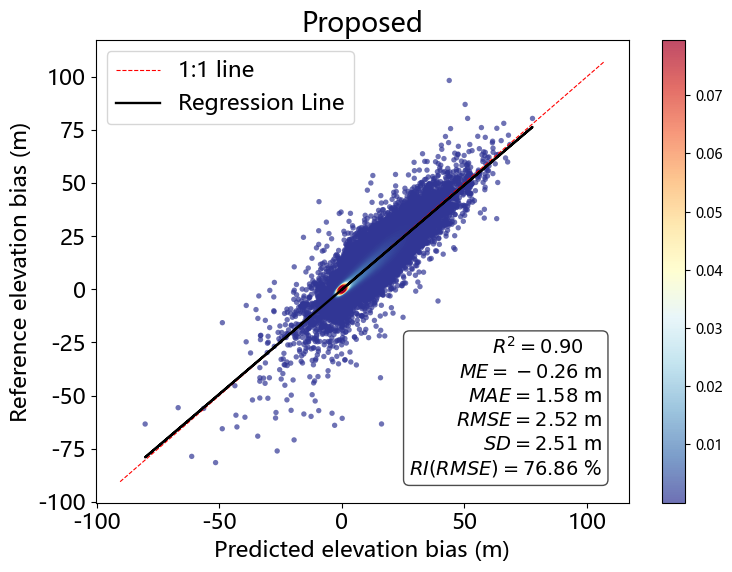

In [ ]:
DrawFigure(PredBias, PredLabels, title="Proposed", imp=76.86, sample_frac=0.01, random_state=42)


In [ ]:

saveModelPath=r"DataModels/Unet1_CompCNN.pth"
cnnmodel= Unet_CNN(in_channels=15).cuda()
PredBias,PredLabels=predictModel(model=cnnmodel,loadModel=saveModelPath,otherPath=otherPaths)

---RawDEM RMSE  Elevation: 10.89,  Slope: 3.03, Curvature: 0.0612
---NSCNN RMSE  Elevation: 2.94,  Slope: 1.67, Curvature: 0.0409
---NSCNN  improvement--   Elevation:73.02%    Slope:45.02%   Curvature:33.14%
---FABDEM RMSE  Elevation: 5.38,  Slope: 2.87, Curvature: 0.0612
---FABDEM  improvement--   Elevation:50.55%    Slope:5.39%   Curvature:0.1315%
---GEDTM30 RMSE  Elevation: 5.31,  Slope: 2.95, Curvature: 0.0631
---GEDTM30DEM  improvement--   Elevation:51.22%    Slope:2.72%   Curvature:-3.0166%
---Fathom RMSE  Elevation: 3.48,  Slope: 2.01, Curvature: 0.0497
---FathomDEM  improvement--   Elevation:67.99%    Slope:33.72%   Curvature:18.7834%
---------Improvemenmt between model and Best -------- Elevation: 5.03   Slope:11.30    Curvature:14.358893 %


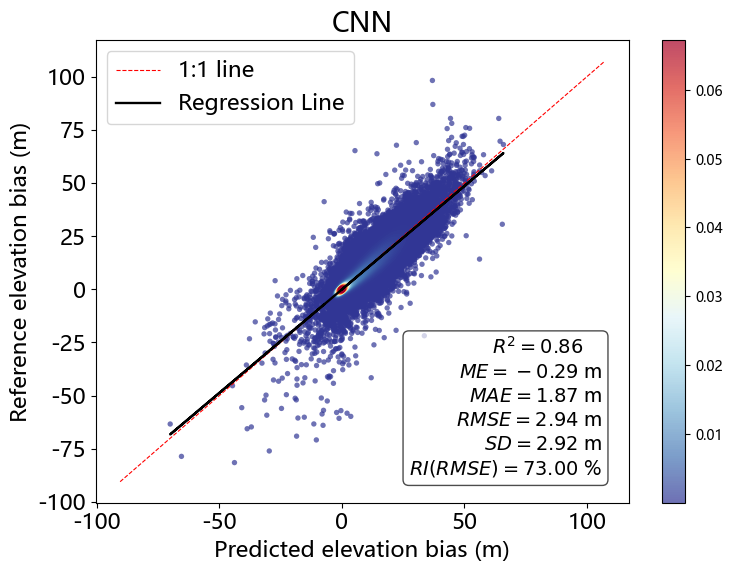

In [ ]:
DrawFigure(PredBias, PredLabels, title="CNN", imp=73, sample_frac=0.01, random_state=42)


### Section 5.1

In [ ]:
"""
1 Change the features
2 sample_ratio=0.5 
"""

In [ ]:

saveModelPath=r"DataModels/Unet05_Proposed.pth"  
cnnmodel= Unet_512_SwinEncoderBlock_SEBlock(in_channels=15).cuda()
PredBias,PredLabels=predictModel(model=cnnmodel,loadModel=saveModelPath,otherPath=otherPaths)

---RawDEM RMSE  Elevation: 10.89,  Slope: 3.03, Curvature: 0.0612
---NSCNN RMSE  Elevation: 2.68,  Slope: 1.55, Curvature: 0.0394
---NSCNN  improvement--   Elevation:75.36%    Slope:49.04%   Curvature:35.71%
---FABDEM RMSE  Elevation: 5.38,  Slope: 2.87, Curvature: 0.0612
---FABDEM  improvement--   Elevation:50.55%    Slope:5.39%   Curvature:0.1315%
---GEDTM30 RMSE  Elevation: 5.31,  Slope: 2.95, Curvature: 0.0631
---GEDTM30DEM  improvement--   Elevation:51.22%    Slope:2.72%   Curvature:-3.0166%
---Fathom RMSE  Elevation: 3.48,  Slope: 2.01, Curvature: 0.0497
---FathomDEM  improvement--   Elevation:67.99%    Slope:33.72%   Curvature:18.7834%
---------Improvemenmt between model and Best -------- Elevation: 7.37   Slope:15.32    Curvature:16.931269 %


In [38]:
saveModelPath=r"DataModels/Unet05_SHAP.pth" 
cnnmodel= Unet_512_SwinEncoderBlock_SEBlock(in_channels=15).cuda()
PredBias,PredLabels=predictModel(model=cnnmodel,loadModel=saveModelPath,otherPath=otherPaths)

---RawDEM RMSE  Elevation: 10.89,  Slope: 3.03, Curvature: 0.0612
---NSCNN RMSE  Elevation: 2.69,  Slope: 1.56, Curvature: 0.0395
---NSCNN  improvement--   Elevation:75.33%    Slope:48.44%   Curvature:35.55%
---FABDEM RMSE  Elevation: 5.38,  Slope: 2.87, Curvature: 0.0612
---FABDEM  improvement--   Elevation:50.55%    Slope:5.39%   Curvature:0.1315%
---GEDTM30 RMSE  Elevation: 5.31,  Slope: 2.95, Curvature: 0.0631
---GEDTM30DEM  improvement--   Elevation:51.22%    Slope:2.72%   Curvature:-3.0166%
---Fathom RMSE  Elevation: 3.48,  Slope: 2.01, Curvature: 0.0497
---FathomDEM  improvement--   Elevation:67.99%    Slope:33.72%   Curvature:18.7834%
---------Improvemenmt between model and Best -------- Elevation: 7.34   Slope:14.72    Curvature:16.771062 %


In [ ]:
saveModelPath=r"DataModels/Unet05_CPCNN.pth" 
cnnmodel= Unet_512_SwinEncoderBlock_SEBlock(in_channels=15).cuda()
PredBias,PredLabels=predictModel(model=cnnmodel,loadModel=saveModelPath,otherPath=otherPaths)

---RawDEM RMSE  Elevation: 10.89,  Slope: 3.03, Curvature: 0.0612
---NSCNN RMSE  Elevation: 2.68,  Slope: 1.57, Curvature: 0.0395
---NSCNN  improvement--   Elevation:75.35%    Slope:48.25%   Curvature:35.46%
---FABDEM RMSE  Elevation: 5.38,  Slope: 2.87, Curvature: 0.0612
---FABDEM  improvement--   Elevation:50.55%    Slope:5.39%   Curvature:0.1315%
---GEDTM30 RMSE  Elevation: 5.31,  Slope: 2.95, Curvature: 0.0631
---GEDTM30DEM  improvement--   Elevation:51.22%    Slope:2.72%   Curvature:-3.0166%
---Fathom RMSE  Elevation: 3.48,  Slope: 2.01, Curvature: 0.0497
---FathomDEM  improvement--   Elevation:67.99%    Slope:33.72%   Curvature:18.7834%
---------Improvemenmt between model and Best -------- Elevation: 7.36   Slope:14.53    Curvature:16.680511 %


In [ ]:
saveModelPath=r"DataModels/Unet05_Gini.path"  
cnnmodel= Unet_512_SwinEncoderBlock_SEBlock(in_channels=15).cuda()
PredBias,PredLabels=predictModel(model=cnnmodel,loadModel=saveModelPath,otherPath=otherPaths)

---RawDEM RMSE  Elevation: 10.89,  Slope: 3.03, Curvature: 0.0612
---NSCNN RMSE  Elevation: 2.79,  Slope: 1.61, Curvature: 0.0402
---NSCNN  improvement--   Elevation:74.36%    Slope:46.75%   Curvature:34.41%
---FABDEM RMSE  Elevation: 5.38,  Slope: 2.87, Curvature: 0.0612
---FABDEM  improvement--   Elevation:50.55%    Slope:5.39%   Curvature:0.1315%
---GEDTM30 RMSE  Elevation: 5.31,  Slope: 2.95, Curvature: 0.0631
---GEDTM30DEM  improvement--   Elevation:51.22%    Slope:2.72%   Curvature:-3.0166%
---Fathom RMSE  Elevation: 3.48,  Slope: 2.01, Curvature: 0.0497
---FathomDEM  improvement--   Elevation:67.99%    Slope:33.72%   Curvature:18.7834%
---------Improvemenmt between model and Best -------- Elevation: 6.37   Slope:13.03    Curvature:15.630257 %


In [ ]:
saveModelPath=r"DataModels/Unet05_MI.path"  
cnnmodel= Unet_512_SwinEncoderBlock_SEBlock(in_channels=15).cuda()
PredBias,PredLabels=predictModel(model=cnnmodel,loadModel=saveModelPath,otherPath=otherPaths)

---RawDEM RMSE  Elevation: 10.89,  Slope: 3.03, Curvature: 0.0612
---NSCNN RMSE  Elevation: 2.78,  Slope: 1.61, Curvature: 0.0406
---NSCNN  improvement--   Elevation:74.49%    Slope:46.95%   Curvature:33.70%
---FABDEM RMSE  Elevation: 5.38,  Slope: 2.87, Curvature: 0.0612
---FABDEM  improvement--   Elevation:50.55%    Slope:5.39%   Curvature:0.1315%
---GEDTM30 RMSE  Elevation: 5.31,  Slope: 2.95, Curvature: 0.0631
---GEDTM30DEM  improvement--   Elevation:51.22%    Slope:2.72%   Curvature:-3.0166%
---Fathom RMSE  Elevation: 3.48,  Slope: 2.01, Curvature: 0.0497
---FathomDEM  improvement--   Elevation:67.99%    Slope:33.72%   Curvature:18.7834%
---------Improvemenmt between model and Best -------- Elevation: 6.50   Slope:13.23    Curvature:14.919718 %


In [ ]:

saveModelPath=r"DataModels/Unet05_CPML.path"  # 
cnnmodel= Unet_512_SwinEncoderBlock_SEBlock(in_channels=15).cuda()
PredBias,PredLabels=predictModel(model=cnnmodel,loadModel=saveModelPath,otherPath=otherPaths)

---RawDEM RMSE  Elevation: 10.89,  Slope: 3.03, Curvature: 0.0612
---NSCNN RMSE  Elevation: 2.75,  Slope: 1.58, Curvature: 0.0390
---NSCNN  improvement--   Elevation:74.71%    Slope:47.99%   Curvature:36.32%
---FABDEM RMSE  Elevation: 5.38,  Slope: 2.87, Curvature: 0.0612
---FABDEM  improvement--   Elevation:50.55%    Slope:5.39%   Curvature:0.1315%
---GEDTM30 RMSE  Elevation: 5.31,  Slope: 2.95, Curvature: 0.0631
---GEDTM30DEM  improvement--   Elevation:51.22%    Slope:2.72%   Curvature:-3.0166%
---Fathom RMSE  Elevation: 3.48,  Slope: 2.01, Curvature: 0.0497
---FathomDEM  improvement--   Elevation:67.99%    Slope:33.72%   Curvature:18.7834%
---------Improvemenmt between model and Best -------- Elevation: 6.72   Slope:14.27    Curvature:17.535215 %


In [ ]:
saveModelPath=r"DataModels/Fathom_F5.path" 
cnnmodel= Unet_512_SwinEncoderBlock_SEBlock(in_channels=5).cuda()
PredBias,PredLabels=predictModel(model=cnnmodel,loadModel=saveModelPath,otherPath=otherPaths)

---RawDEM RMSE  Elevation: 10.89,  Slope: 3.03, Curvature: 0.0612
---NSCNN RMSE  Elevation: 3.65,  Slope: 2.01, Curvature: 0.0467
---NSCNN  improvement--   Elevation:66.50%    Slope:33.61%   Curvature:23.68%
---FABDEM RMSE  Elevation: 5.38,  Slope: 2.87, Curvature: 0.0612
---FABDEM  improvement--   Elevation:50.55%    Slope:5.39%   Curvature:0.1315%
---GEDTM30 RMSE  Elevation: 5.31,  Slope: 2.95, Curvature: 0.0631
---GEDTM30DEM  improvement--   Elevation:51.22%    Slope:2.72%   Curvature:-3.0166%
---Fathom RMSE  Elevation: 3.48,  Slope: 2.01, Curvature: 0.0497
---FathomDEM  improvement--   Elevation:67.99%    Slope:33.72%   Curvature:18.7834%
---------Improvemenmt between model and Best -------- Elevation: -1.49   Slope:-0.11    Curvature:4.896955 %


In [ ]:
saveModelPath=r"DataModels/FeatureSet2.path" 
cnnmodel= Unet_512_SwinEncoderBlock_SEBlock(in_channels=7).cuda()
PredBias,PredLabels=predictModel(model=cnnmodel,loadModel=saveModelPath,otherPath=otherPaths)

---RawDEM RMSE  Elevation: 10.89,  Slope: 3.03, Curvature: 0.0612
---NSCNN RMSE  Elevation: 3.86,  Slope: 2.05, Curvature: 0.0491
---NSCNN  improvement--   Elevation:64.51%    Slope:32.42%   Curvature:19.76%
---FABDEM RMSE  Elevation: 5.38,  Slope: 2.87, Curvature: 0.0612
---FABDEM  improvement--   Elevation:50.55%    Slope:5.39%   Curvature:0.1315%
---GEDTM30 RMSE  Elevation: 5.31,  Slope: 2.95, Curvature: 0.0631
---GEDTM30DEM  improvement--   Elevation:51.22%    Slope:2.72%   Curvature:-3.0166%
---Fathom RMSE  Elevation: 3.48,  Slope: 2.01, Curvature: 0.0497
---FathomDEM  improvement--   Elevation:67.99%    Slope:33.72%   Curvature:18.7834%
---------Improvemenmt between model and Best -------- Elevation: -3.48   Slope:-1.30    Curvature:0.981253 %


In [ ]:
saveModelPath=r"DataModels/FeatureSet3.path" 
cnnmodel= Unet_512_SwinEncoderBlock_SEBlock(in_channels=6).cuda()

PredBias,PredLabels=predictModel(model=cnnmodel,loadModel=saveModelPath,otherPath=otherPaths)

---RawDEM RMSE  Elevation: 10.89,  Slope: 3.03, Curvature: 0.0612
---NSCNN RMSE  Elevation: 3.86,  Slope: 2.07, Curvature: 0.0488
---NSCNN  improvement--   Elevation:64.53%    Slope:31.68%   Curvature:20.28%
---FABDEM RMSE  Elevation: 5.38,  Slope: 2.87, Curvature: 0.0612
---FABDEM  improvement--   Elevation:50.55%    Slope:5.39%   Curvature:0.1315%
---GEDTM30 RMSE  Elevation: 5.31,  Slope: 2.95, Curvature: 0.0631
---GEDTM30DEM  improvement--   Elevation:51.22%    Slope:2.72%   Curvature:-3.0166%
---Fathom RMSE  Elevation: 3.48,  Slope: 2.01, Curvature: 0.0497
---FathomDEM  improvement--   Elevation:67.99%    Slope:33.72%   Curvature:18.7834%
---------Improvemenmt between model and Best -------- Elevation: -3.46   Slope:-2.04    Curvature:1.492099 %


In [ ]:
saveModelPath=r"DataModels/All0_5_Allmodel_OneTree.path" 
cnnmodel= Unet_512_SwinEncoderBlock_SEBlock(in_channels=13).cuda()
PredBias,PredLabels=predictModel(model=cnnmodel,loadModel=saveModelPath,otherPath=otherPaths)

---RawDEM RMSE  Elevation: 10.89,  Slope: 3.03, Curvature: 0.0612
---NSCNN RMSE  Elevation: 2.80,  Slope: 1.62, Curvature: 0.0397
---NSCNN  improvement--   Elevation:74.31%    Slope:46.66%   Curvature:35.12%
---FABDEM RMSE  Elevation: 5.38,  Slope: 2.87, Curvature: 0.0612
---FABDEM  improvement--   Elevation:50.55%    Slope:5.39%   Curvature:0.1315%
---GEDTM30 RMSE  Elevation: 5.31,  Slope: 2.95, Curvature: 0.0631
---GEDTM30DEM  improvement--   Elevation:51.22%    Slope:2.72%   Curvature:-3.0166%
---Fathom RMSE  Elevation: 3.48,  Slope: 2.01, Curvature: 0.0497
---FathomDEM  improvement--   Elevation:67.99%    Slope:33.72%   Curvature:18.7834%
---------Improvemenmt between model and Best -------- Elevation: 6.32   Slope:12.94    Curvature:16.340584 %


### Section 5.3

In [ ]:
"""
1 SHAPCNN
2 sample_ratio=0.5 
"""

In [ ]:

saveModelPath=r"DataModels/All_CNNTransformer_MSE.path"  
cnnmodel= Unet_512_SwinEncoderBlock_SEBlock(in_channels=15).cuda()
PredBias,PredLabels=predictModel(model=cnnmodel,loadModel=saveModelPath,otherPath=otherPaths)

---RawDEM RMSE  Elevation: 10.89,  Slope: 3.03, Curvature: 0.0612
---NSCNN RMSE  Elevation: 2.59,  Slope: 1.53, Curvature: 0.0384
---NSCNN  improvement--   Elevation:76.23%    Slope:49.42%   Curvature:37.25%
---FABDEM RMSE  Elevation: 5.38,  Slope: 2.87, Curvature: 0.0612
---FABDEM  improvement--   Elevation:50.55%    Slope:5.39%   Curvature:0.1315%
---GEDTM30 RMSE  Elevation: 5.31,  Slope: 2.95, Curvature: 0.0631
---GEDTM30DEM  improvement--   Elevation:51.22%    Slope:2.72%   Curvature:-3.0166%
---Fathom RMSE  Elevation: 3.48,  Slope: 2.01, Curvature: 0.0497
---FathomDEM  improvement--   Elevation:67.99%    Slope:33.72%   Curvature:18.7834%
---------Improvemenmt between model and Best -------- Elevation: 8.24   Slope:15.70    Curvature:18.462372 %


In [ ]:

saveModelPath=r"I:\DC_HR\Models_MR\STD_CNNSHAP15\Abliation\Further\All_CNNTransformer.path" 
cnnmodel=Unet_512_SwinEncoderBlock(in_channels=15).cuda()
PredBias,PredLabels=predictModel(model=cnnmodel,loadModel=saveModelPath,otherPath=otherPaths)

---RawDEM RMSE  Elevation: 10.89,  Slope: 3.03, Curvature: 0.0612
---NSCNN RMSE  Elevation: 2.56,  Slope: 1.51, Curvature: 0.0375
---NSCNN  improvement--   Elevation:76.50%    Slope:50.07%   Curvature:38.69%
---FABDEM RMSE  Elevation: 5.38,  Slope: 2.87, Curvature: 0.0612
---FABDEM  improvement--   Elevation:50.55%    Slope:5.39%   Curvature:0.1315%
---GEDTM30 RMSE  Elevation: 5.31,  Slope: 2.95, Curvature: 0.0631
---GEDTM30DEM  improvement--   Elevation:51.22%    Slope:2.72%   Curvature:-3.0166%
---Fathom RMSE  Elevation: 3.48,  Slope: 2.01, Curvature: 0.0497
---FathomDEM  improvement--   Elevation:67.99%    Slope:33.72%   Curvature:18.7834%
---------Improvemenmt between model and Best -------- Elevation: 8.51   Slope:16.35    Curvature:19.907778 %


In [9]:

saveModelPath=r"DataModels/All_Unet_SEBlock_512.path" 
cnnmodel=Unet_512_SEBlock(in_channels=15).cuda()
PredBias,PredLabels=predictModel(model=cnnmodel,loadModel=saveModelPath,otherPath=otherPaths)

---RawDEM RMSE  Elevation: 10.89,  Slope: 3.03, Curvature: 0.0612
---NSCNN RMSE  Elevation: 2.81,  Slope: 1.58, Curvature: 0.0389
---NSCNN  improvement--   Elevation:74.20%    Slope:47.85%   Curvature:36.49%
---FABDEM RMSE  Elevation: 5.38,  Slope: 2.87, Curvature: 0.0612
---FABDEM  improvement--   Elevation:50.55%    Slope:5.39%   Curvature:0.1315%
---GEDTM30 RMSE  Elevation: 5.31,  Slope: 2.95, Curvature: 0.0631
---GEDTM30DEM  improvement--   Elevation:51.22%    Slope:2.72%   Curvature:-3.0166%
---Fathom RMSE  Elevation: 3.48,  Slope: 2.01, Curvature: 0.0497
---FathomDEM  improvement--   Elevation:67.99%    Slope:33.72%   Curvature:18.7834%
---------Improvemenmt between model and Best -------- Elevation: 6.21   Slope:14.13    Curvature:17.703918 %


In [10]:

saveModelPath=r"DataModels/All_Unet_512.path"  
cnnmodel=Unet_512(in_channels=15).cuda()
PredBias,PredLabels=predictModel(model=cnnmodel,loadModel=saveModelPath,otherPath=otherPaths)

---RawDEM RMSE  Elevation: 10.89,  Slope: 3.03, Curvature: 0.0612
---NSCNN RMSE  Elevation: 2.81,  Slope: 1.60, Curvature: 0.0391
---NSCNN  improvement--   Elevation:74.19%    Slope:47.17%   Curvature:36.23%
---FABDEM RMSE  Elevation: 5.38,  Slope: 2.87, Curvature: 0.0612
---FABDEM  improvement--   Elevation:50.55%    Slope:5.39%   Curvature:0.1315%
---GEDTM30 RMSE  Elevation: 5.31,  Slope: 2.95, Curvature: 0.0631
---GEDTM30DEM  improvement--   Elevation:51.22%    Slope:2.72%   Curvature:-3.0166%
---Fathom RMSE  Elevation: 3.48,  Slope: 2.01, Curvature: 0.0497
---FathomDEM  improvement--   Elevation:67.99%    Slope:33.72%   Curvature:18.7834%
---------Improvemenmt between model and Best -------- Elevation: 6.20   Slope:13.46    Curvature:17.441890 %


# HRDEMs

In [ ]:
"""
The data volume is too large to upload. Please refer to the run history.
"""

### Section 4.2.2

In [13]:


cols_names = [
    "Pid","IDW", "FABDEM", "GEDTM30", "FathomDEM", "HRDEM", "Lon", "Lat","LandCover", "LandForm",
    "ForestCoverage", "ForestHeight", "ForestHeight10", "ForestHeight30",
    "BuildingHeight90", "Pop", "NightLight",
    "Aspect", "Hillshade", "Curvature", "ProfileCur", "PlanCur", 
    "DEM", "STDDEM", "Max_MinDEM", "Mean_MinDEM", "deltMeanDEM", "deltMedianDEM", "deltMinDEM", "deltMaxDEM",
    "Slope", "MaxSlope", "STDSlope", "Mean_MinSlope", "Max_MinSlope", "deltMeanSlope", "SOS", "SOA","HEL","FCLoss","FCGain","NIR","RGB","SAR_VV","SAR_VH"
]


mean_std_path=r"DataModels/mean_std.npz"

# Which is HA 1-10
Validation_list=["WestAmerica_10","WestAmerica_44","EastAmerica_5","France20","UK3",'NorthLand','WestCoast_validation','almeria',  'canyon',  'ebro', 'la', 'trentino']


In [15]:

saveModelPath=r"DataModels/Unet1_Proposed.pth"  
cnnmodel= Unet_512_SwinEncoderBlock_SEBlock(in_channels=15).cuda()

selected_features= ['BuildingHeight90', 'ForestHeight', 'ForestHeight10', 'ForestHeight30', 
                    'DEM', 'HEL', 'ForestCoverage', 'Aspect', 'Hillshade', 'NIR', 'deltMinDEM', 'RGB', 'SAR_VV', 'Curvature', 'FCLoss']


print(saveModelPath, selected_features)

ele_list=[]
slope_list=[]
cur_list=[]
for area in  Validation_list:
    
    numpy_Mountain = np.load(r"I:\DC_HR\NPZ_HRDEMs\FullAreas\Numpy_{}_64.npy".format(area)) 
    
    print(f"------------------- {area}------------------------")
    
    genTrainingData_HRDEM(numpy_Mountain,cols_names=cols_names,selected_features=selected_features,mean_std_path=mean_std_path,IsEmpty=False) #  Full Areas
    ele,slope,cur=predictModel_validation(model=cnnmodel,loadModel=saveModelPath)
    print()



DataModels/Unet1_Proposed.pth ['BuildingHeight90', 'ForestHeight', 'ForestHeight10', 'ForestHeight30', 'DEM', 'HEL', 'ForestCoverage', 'Aspect', 'Hillshade', 'NIR', 'deltMinDEM', 'RGB', 'SAR_VV', 'Curvature', 'FCLoss']
------------------- WestAmerica_10------------------------
---RawDEM RMSE  Elevation: 14.43,  Slope: 4.00, Curvature: 0.0612
---NSCNN RMSE  Elevation: 3.02,  Slope: 2.01, Curvature: 0.0322

------------------- WestAmerica_44------------------------
---RawDEM RMSE  Elevation: 11.10,  Slope: 3.44, Curvature: 0.0469
---NSCNN RMSE  Elevation: 2.08,  Slope: 1.40, Curvature: 0.0223

------------------- EastAmerica_5------------------------
---RawDEM RMSE  Elevation: 12.29,  Slope: 3.86, Curvature: 0.0478
---NSCNN RMSE  Elevation: 2.47,  Slope: 1.61, Curvature: 0.0211

------------------- France20------------------------
---RawDEM RMSE  Elevation: 7.35,  Slope: 2.68, Curvature: 0.1162
---NSCNN RMSE  Elevation: 4.33,  Slope: 1.87, Curvature: 0.0933

------------------- UK3------

In [19]:

saveModelPath=r"DataModels/Unet1_CompCNN.pth"
cnnmodel= Unet_CNN(in_channels=15).cuda()

selected_features= ['BuildingHeight90', 'ForestHeight', 'ForestHeight10', 'ForestHeight30', 
                    'DEM', 'HEL', 'ForestCoverage', 'Aspect', 'Hillshade', 'NIR', 'deltMinDEM', 'RGB', 'SAR_VV', 'Curvature', 'FCLoss']


print(saveModelPath, selected_features)

ele_list=[]
slope_list=[]
cur_list=[]
for area in  Validation_list:
    
    numpy_Mountain = np.load(r"I:\DC_HR\NPZ_HRDEMs\FullAreas\Numpy_{}_64.npy".format(area)) 
    
    print(f"------------------- {area}------------------------")
    
    genTrainingData_HRDEM(numpy_Mountain,cols_names=cols_names,selected_features=selected_features,mean_std_path=mean_std_path,IsEmpty=False) #  Full Areas
    ele,slope,cur=predictModel_validation(model=cnnmodel,loadModel=saveModelPath)
    print()



DataModels/Unet1_CompCNN.pth ['BuildingHeight90', 'ForestHeight', 'ForestHeight10', 'ForestHeight30', 'DEM', 'HEL', 'ForestCoverage', 'Aspect', 'Hillshade', 'NIR', 'deltMinDEM', 'RGB', 'SAR_VV', 'Curvature', 'FCLoss']
------------------- WestAmerica_10------------------------
---RawDEM RMSE  Elevation: 14.43,  Slope: 4.00, Curvature: 0.0612
---NSCNN RMSE  Elevation: 3.56,  Slope: 2.25, Curvature: 0.0359

------------------- WestAmerica_44------------------------
---RawDEM RMSE  Elevation: 11.10,  Slope: 3.44, Curvature: 0.0469
---NSCNN RMSE  Elevation: 2.57,  Slope: 1.68, Curvature: 0.0253

------------------- EastAmerica_5------------------------
---RawDEM RMSE  Elevation: 12.29,  Slope: 3.86, Curvature: 0.0478
---NSCNN RMSE  Elevation: 3.03,  Slope: 1.92, Curvature: 0.0246

------------------- France20------------------------
---RawDEM RMSE  Elevation: 7.35,  Slope: 2.68, Curvature: 0.1162
---NSCNN RMSE  Elevation: 4.73,  Slope: 2.05, Curvature: 0.0985

------------------- UK3-------

### Section 5.3

In [ ]:

saveModelPath=r"DataModels/All_CNNTransformer.path"  
cnnmodel= Unet_512_SwinEncoderBlock(in_channels=15).cuda()

selected_features= ['BuildingHeight90', 'ForestHeight', 'ForestHeight10', 'ForestHeight30', 
                    'DEM', 'HEL', 'ForestCoverage', 'Aspect', 'Hillshade', 'NIR', 'deltMinDEM', 'RGB', 'SAR_VV', 'Curvature', 'FCLoss']


print(saveModelPath, selected_features)

ele_list=[]
slope_list=[]
cur_list=[]
for area in  Validation_list:
    
    numpy_Mountain = np.load(r"I:\DC_HR\NPZ_HRDEMs\FullAreas\Numpy_{}_64.npy".format(area)) 
    
    print(f"------------------- {area}------------------------")
    
    genTrainingData_HRDEM(numpy_Mountain,cols_names=cols_names,selected_features=selected_features,mean_std_path=mean_std_path,IsEmpty=False) #  Full Areas
    ele,slope,cur=predictModel_validation(model=cnnmodel,loadModel=saveModelPath)
    
    ele_list.append(ele)
    slope_list.append(slope)
    cur_list.append(cur)

print(f"Mean Ele:{sum(ele_list)/12 :0.2f}   Slope:{sum(slope_list)/12:0.2f}   Cur:{sum(cur_list)/12 :0.2f}")



I:\DC_HR\Models_MR\STD_CNNSHAP15\Abliation\Further\All_CNNTransformer.path ['BuildingHeight90', 'ForestHeight', 'ForestHeight10', 'ForestHeight30', 'DEM', 'HEL', 'ForestCoverage', 'Aspect', 'Hillshade', 'NIR', 'deltMinDEM', 'RGB', 'SAR_VV', 'Curvature', 'FCLoss']
------------------- WestAmerica_10------------------------
------------------- WestAmerica_44------------------------
------------------- EastAmerica_5------------------------
------------------- France20------------------------
------------------- UK3------------------------
------------------- NorthLand------------------------
------------------- WestCoast_validation------------------------
------------------- almeria------------------------
------------------- canyon------------------------
------------------- ebro------------------------
------------------- la------------------------
------------------- trentino------------------------
Mean Ele:51.83   Slope:39.49   Cur:34.23


In [ ]:


saveModelPath=r"DataModels/All_CNNTransformer_MSE.path"  
cnnmodel= Unet_512_SwinEncoderBlock_SEBlock(in_channels=15).cuda()

selected_features= ['BuildingHeight90', 'ForestHeight', 'ForestHeight10', 'ForestHeight30', 
                    'DEM', 'HEL', 'ForestCoverage', 'Aspect', 'Hillshade', 'NIR', 'deltMinDEM', 'RGB', 'SAR_VV', 'Curvature', 'FCLoss']


print(saveModelPath, selected_features)

ele_list=[]
slope_list=[]
cur_list=[]
for area in  Validation_list:
    
    numpy_Mountain = np.load(r"I:\DC_HR\NPZ_HRDEMs\FullAreas\Numpy_{}_64.npy".format(area)) #  Full Areas
    
    print(f"------------------- {area}------------------------")
    
    genTrainingData_HRDEM(numpy_Mountain,cols_names=cols_names,selected_features=selected_features,mean_std_path=mean_std_path,IsEmpty=False)
    ele,slope,cur=predictModel_validation(model=cnnmodel,loadModel=saveModelPath)
    
    ele_list.append(ele)
    slope_list.append(slope)
    cur_list.append(cur)

print(f"Mean Ele:{sum(ele_list)/12 :0.2f}   Slope:{sum(slope_list)/12:0.2f}   Cur:{sum(cur_list)/12 :0.2f}")



I:\DC_HR\Models_MR\STD_CNNSHAP15\Abliation\Further\All_CNNTransformer_MSE.path ['BuildingHeight90', 'ForestHeight', 'ForestHeight10', 'ForestHeight30', 'DEM', 'HEL', 'ForestCoverage', 'Aspect', 'Hillshade', 'NIR', 'deltMinDEM', 'RGB', 'SAR_VV', 'Curvature', 'FCLoss']
Mean Ele:51.68   Slope:38.58   Cur:33.38


In [ ]:


saveModelPath=r"DataModels/All_Unet_SEBlock_512.path"  
cnnmodel= Unet_512_SEBlock(in_channels=15).cuda()

selected_features= ['BuildingHeight90', 'ForestHeight', 'ForestHeight10', 'ForestHeight30', 
                    'DEM', 'HEL', 'ForestCoverage', 'Aspect', 'Hillshade', 'NIR', 'deltMinDEM', 'RGB', 'SAR_VV', 'Curvature', 'FCLoss']


print(saveModelPath, selected_features)

ele_list=[]
slope_list=[]
cur_list=[]
for area in  Validation_list:
    
    numpy_Mountain = np.load(r"I:\DC_HR\NPZ_HRDEMs\FullAreas\Numpy_{}_64.npy".format(area)) #  Full Areas
    
    # print(f"------------------- {area}------------------------")
    
    genTrainingData_HRDEM(numpy_Mountain,cols_names=cols_names,selected_features=selected_features,mean_std_path=mean_std_path,IsEmpty=False)
    ele,slope,cur=predictModel_validation(model=cnnmodel,loadModel=saveModelPath)
    
    ele_list.append(ele)
    slope_list.append(slope)
    cur_list.append(cur)

print(f"Mean Ele:{sum(ele_list)/12 :0.2f}   Slope:{sum(slope_list)/12:0.2f}   Cur:{sum(cur_list)/12 :0.2f}")



I:\DC_HR\Models_MR\STD_CNNSHAP15\Abliation\All_Unet_SEBlock_512.path ['BuildingHeight90', 'ForestHeight', 'ForestHeight10', 'ForestHeight30', 'DEM', 'HEL', 'ForestCoverage', 'Aspect', 'Hillshade', 'NIR', 'deltMinDEM', 'RGB', 'SAR_VV', 'Curvature', 'FCLoss']
Mean Ele:49.26   Slope:36.13   Cur:31.75


In [ ]:

saveModelPath=r"DataModels/All_Unet_SEBlock_512.path"  
cnnmodel= Unet_512(in_channels=15).cuda()

selected_features= ['BuildingHeight90', 'ForestHeight', 'ForestHeight10', 'ForestHeight30', 
                    'DEM', 'HEL', 'ForestCoverage', 'Aspect', 'Hillshade', 'NIR', 'deltMinDEM', 'RGB', 'SAR_VV', 'Curvature', 'FCLoss']


print(saveModelPath, selected_features)

ele_list=[]
slope_list=[]
cur_list=[]
for area in  Validation_list:
    
    numpy_Mountain = np.load(r"I:\DC_HR\NPZ_HRDEMs\FullAreas\Numpy_{}_64.npy".format(area)) #  Full Areas
    
    # print(f"------------------- {area}------------------------")
    
    genTrainingData_HRDEM(numpy_Mountain,cols_names=cols_names,selected_features=selected_features,mean_std_path=mean_std_path,IsEmpty=False)
    ele,slope,cur=predictModel_validation(model=cnnmodel,loadModel=saveModelPath)
    
    ele_list.append(ele)
    slope_list.append(slope)
    cur_list.append(cur)

print(f"Mean Ele:{sum(ele_list)/12 :0.2f}   Slope:{sum(slope_list)/12:0.2f}   Cur:{sum(cur_list)/12 :0.2f}")



I:\DC_HR\Models_MR\STD_CNNSHAP15\Abliation\All_Unet_512.path ['BuildingHeight90', 'ForestHeight', 'ForestHeight10', 'ForestHeight30', 'DEM', 'HEL', 'ForestCoverage', 'Aspect', 'Hillshade', 'NIR', 'deltMinDEM', 'RGB', 'SAR_VV', 'Curvature', 'FCLoss']
Mean Ele:49.06   Slope:35.95   Cur:31.26


### Section 5.1

In [15]:

saveModelPath=r"DataModels/Unet05_CPCNN.pth"  #  
cnnmodel= Unet_512_SwinEncoderBlock_SEBlock(in_channels=15).cuda()
# CNN Permulation
selected_features=['DEM', 'BuildingHeight90', 'ForestHeight', 'ForestHeight10', 'ForestHeight30','ForestCoverage', 'HEL', 
                  'deltMeanDEM',  'NIR', 'FCLoss', 'FCGain', 'SAR_VV', 'Aspect', 'STDDEM','Hillshade' ]

print(saveModelPath, selected_features)

ele_list=[]
slope_list=[]
cur_list=[]
for area in  Validation_list:
    
    numpy_Mountain = np.load(r"I:\DC_HR\NPZ_HRDEMs\FullAreas\Numpy_{}_64.npy".format(area)) #  Full Areas
    
    # print(f"------------------- {area}------------------------")
    
    genTrainingData_HRDEM(numpy_Mountain,cols_names=cols_names,selected_features=selected_features,mean_std_path=mean_std_path,IsEmpty=False)
    ele,slope,cur=predictModel_validation(model=cnnmodel,loadModel=saveModelPath)
    
    ele_list.append(ele)
    slope_list.append(slope)
    cur_list.append(cur)

print(f"Mean Ele:{sum(ele_list)/12 :0.2f}   Slope:{sum(slope_list)/12:0.2f}   Cur:{sum(cur_list)/12 :0.2f}")


DataModels/Unet05_CPCNN.pth ['DEM', 'BuildingHeight90', 'ForestHeight', 'ForestHeight10', 'ForestHeight30', 'ForestCoverage', 'HEL', 'deltMeanDEM', 'NIR', 'FCLoss', 'FCGain', 'SAR_VV', 'Aspect', 'STDDEM', 'Hillshade']
Mean Ele:50.17   Slope:37.55   Cur:31.40


In [16]:

saveModelPath=r"DataModels/Unet05_Gini.path"  #
cnnmodel= Unet_512_SwinEncoderBlock_SEBlock(in_channels=15).cuda()
# Gini
selected_features=['BuildingHeight90','DEM', 'Pop', 'ForestHeight10', 'NightLight', 'ForestHeight', 'ForestCoverage', 
                  'HEL', 'RGB', 'Aspect', 'ForestHeight30', 'NIR', 'SAR_VH', 'MaxSlope', 'Hillshade']

print(saveModelPath, selected_features)

ele_list=[]
slope_list=[]
cur_list=[]
for area in  Validation_list:
    
    numpy_Mountain = np.load(r"I:\DC_HR\NPZ_HRDEMs\FullAreas\Numpy_{}_64.npy".format(area)) #  Full Areas
    
    # print(f"------------------- {area}------------------------")
    
    genTrainingData_HRDEM(numpy_Mountain,cols_names=cols_names,selected_features=selected_features,mean_std_path=mean_std_path,IsEmpty=False)
    ele,slope,cur=predictModel_validation(model=cnnmodel,loadModel=saveModelPath)
    
    ele_list.append(ele)
    slope_list.append(slope)
    cur_list.append(cur)

print(f"Mean Ele:{sum(ele_list)/12 :0.2f}   Slope:{sum(slope_list)/12:0.2f}   Cur:{sum(cur_list)/12 :0.2f}")


DataModels/Unet05_Gini.path ['BuildingHeight90', 'DEM', 'Pop', 'ForestHeight10', 'NightLight', 'ForestHeight', 'ForestCoverage', 'HEL', 'RGB', 'Aspect', 'ForestHeight30', 'NIR', 'SAR_VH', 'MaxSlope', 'Hillshade']
---RawDEM RMSE  Elevation: 14.43,  Slope: 4.00, Curvature: 0.0612
---NSCNN RMSE  Elevation: 3.38,  Slope: 2.19, Curvature: 0.0351
---RawDEM RMSE  Elevation: 11.10,  Slope: 3.44, Curvature: 0.0469
---NSCNN RMSE  Elevation: 2.46,  Slope: 1.61, Curvature: 0.0256
---RawDEM RMSE  Elevation: 12.29,  Slope: 3.86, Curvature: 0.0478
---NSCNN RMSE  Elevation: 2.83,  Slope: 1.80, Curvature: 0.0231
---RawDEM RMSE  Elevation: 7.35,  Slope: 2.68, Curvature: 0.1162
---NSCNN RMSE  Elevation: 4.60,  Slope: 2.04, Curvature: 0.0982
---RawDEM RMSE  Elevation: 3.52,  Slope: 2.26, Curvature: 0.0318
---NSCNN RMSE  Elevation: 1.83,  Slope: 1.26, Curvature: 0.0190
---RawDEM RMSE  Elevation: 8.54,  Slope: 2.79, Curvature: 0.0329
---NSCNN RMSE  Elevation: 2.39,  Slope: 1.48, Curvature: 0.0178
---RawDEM 

In [17]:

saveModelPath=r"DataModels/Unet05_MI.path"  #
cnnmodel= Unet_512_SwinEncoderBlock_SEBlock(in_channels=15).cuda()
# MInformationn
selected_features=['BuildingHeight90', 'ForestHeight', 'ForestHeight10', 'ForestHeight30', 'ForestCoverage','HEL', 
                   'RGB',  'SAR_VH', 'MaxSlope', 'DEM', 'Pop', 'Max_MinSlope', 'Hillshade', 'ProfileCur', 'NightLight']

print(saveModelPath, selected_features)

ele_list=[]
slope_list=[]
cur_list=[]
for area in  Validation_list:
    
    numpy_Mountain = np.load(r"I:\DC_HR\NPZ_HRDEMs\FullAreas\Numpy_{}_64.npy".format(area)) #  Full Areas
    
    genTrainingData_HRDEM(numpy_Mountain,cols_names=cols_names,selected_features=selected_features,mean_std_path=mean_std_path,IsEmpty=False)
    ele,slope,cur=predictModel_validation(model=cnnmodel,loadModel=saveModelPath)
    
    ele_list.append(ele)
    slope_list.append(slope)
    cur_list.append(cur)

print(f"Mean Ele:{sum(ele_list)/12 :0.2f}   Slope:{sum(slope_list)/12:0.2f}   Cur:{sum(cur_list)/12 :0.2f}")


DataModels/Unet05_MI.path ['BuildingHeight90', 'ForestHeight', 'ForestHeight10', 'ForestHeight30', 'ForestCoverage', 'HEL', 'RGB', 'SAR_VH', 'MaxSlope', 'DEM', 'Pop', 'Max_MinSlope', 'Hillshade', 'ProfileCur', 'NightLight']
---RawDEM RMSE  Elevation: 14.43,  Slope: 4.00, Curvature: 0.0612
---NSCNN RMSE  Elevation: 3.36,  Slope: 2.19, Curvature: 0.0350
---RawDEM RMSE  Elevation: 11.10,  Slope: 3.44, Curvature: 0.0469
---NSCNN RMSE  Elevation: 2.34,  Slope: 1.53, Curvature: 0.0247
---RawDEM RMSE  Elevation: 12.29,  Slope: 3.86, Curvature: 0.0478
---NSCNN RMSE  Elevation: 2.83,  Slope: 1.79, Curvature: 0.0230
---RawDEM RMSE  Elevation: 7.35,  Slope: 2.68, Curvature: 0.1162
---NSCNN RMSE  Elevation: 4.61,  Slope: 1.98, Curvature: 0.0989
---RawDEM RMSE  Elevation: 3.52,  Slope: 2.26, Curvature: 0.0318
---NSCNN RMSE  Elevation: 1.78,  Slope: 1.24, Curvature: 0.0188
---RawDEM RMSE  Elevation: 8.54,  Slope: 2.79, Curvature: 0.0329
---NSCNN RMSE  Elevation: 2.45,  Slope: 1.48, Curvature: 0.0180

In [18]:

saveModelPath=r"DataModels/Unet05_CPML.path"  #
cnnmodel= Unet_512_SwinEncoderBlock_SEBlock(in_channels=15).cuda()
# ML Permulation
selected_features=['BuildingHeight90', 'ForestHeight', 'ForestHeight10', 'ForestHeight30','ForestCoverage', 
                    'Aspect', 'Hillshade','DEM', 'HEL',  'RGB', 'NIR',"Pop", 'SAR_VH', 'deltMinDEM','NightLight']

print(saveModelPath, selected_features)

ele_list=[]
slope_list=[]
cur_list=[]
for area in  Validation_list:
    
    numpy_Mountain = np.load(r"I:\DC_HR\NPZ_HRDEMs\FullAreas\Numpy_{}_64.npy".format(area)) #  Full Areas
    
    genTrainingData_HRDEM(numpy_Mountain,cols_names=cols_names,selected_features=selected_features,mean_std_path=mean_std_path,IsEmpty=False)
    ele,slope,cur=predictModel_validation(model=cnnmodel,loadModel=saveModelPath)
    
    ele_list.append(ele)
    slope_list.append(slope)
    cur_list.append(cur)

print(f"Mean Ele:{sum(ele_list)/12 :0.2f}   Slope:{sum(slope_list)/12:0.2f}   Cur:{sum(cur_list)/12 :0.2f}")


DataModels/Unet05_CPML.path ['BuildingHeight90', 'ForestHeight', 'ForestHeight10', 'ForestHeight30', 'ForestCoverage', 'Aspect', 'Hillshade', 'DEM', 'HEL', 'RGB', 'NIR', 'Pop', 'SAR_VH', 'deltMinDEM', 'NightLight']
---RawDEM RMSE  Elevation: 14.43,  Slope: 4.00, Curvature: 0.0612
---NSCNN RMSE  Elevation: 3.29,  Slope: 2.12, Curvature: 0.0337
---RawDEM RMSE  Elevation: 11.10,  Slope: 3.44, Curvature: 0.0469
---NSCNN RMSE  Elevation: 2.33,  Slope: 1.52, Curvature: 0.0238
---RawDEM RMSE  Elevation: 12.29,  Slope: 3.86, Curvature: 0.0478
---NSCNN RMSE  Elevation: 2.84,  Slope: 1.76, Curvature: 0.0227
---RawDEM RMSE  Elevation: 7.35,  Slope: 2.68, Curvature: 0.1162
---NSCNN RMSE  Elevation: 4.53,  Slope: 1.94, Curvature: 0.0958
---RawDEM RMSE  Elevation: 3.52,  Slope: 2.26, Curvature: 0.0318
---NSCNN RMSE  Elevation: 1.94,  Slope: 1.26, Curvature: 0.0186
---RawDEM RMSE  Elevation: 8.54,  Slope: 2.79, Curvature: 0.0329
---NSCNN RMSE  Elevation: 2.33,  Slope: 1.43, Curvature: 0.0174
---RawDE

In [19]:

saveModelPath=r"DataModels/Fathom_F5.path" 
cnnmodel= Unet_512_SwinEncoderBlock_SEBlock(in_channels=5).cuda()
# Fset 1
selected_features=['BuildingHeight90', 'ForestHeight10', 'DEM', 'SAR_VV','SAR_VH']

print(saveModelPath, selected_features)

ele_list=[]
slope_list=[]
cur_list=[]
for area in  Validation_list:
    
    numpy_Mountain = np.load(r"I:\DC_HR\NPZ_HRDEMs\FullAreas\Numpy_{}_64.npy".format(area)) #  Full Areas
    
    genTrainingData_HRDEM(numpy_Mountain,cols_names=cols_names,selected_features=selected_features,mean_std_path=mean_std_path,IsEmpty=False)
    ele,slope,cur=predictModel_validation(model=cnnmodel,loadModel=saveModelPath)
    
    ele_list.append(ele)
    slope_list.append(slope)
    cur_list.append(cur)

print(f"Mean Ele:{sum(ele_list)/12 :0.2f}   Slope:{sum(slope_list)/12:0.2f}   Cur:{sum(cur_list)/12 :0.2f}")


DataModels/Fathom_F5.path ['BuildingHeight90', 'ForestHeight10', 'DEM', 'SAR_VV', 'SAR_VH']
---RawDEM RMSE  Elevation: 14.43,  Slope: 4.00, Curvature: 0.0612
---NSCNN RMSE  Elevation: 4.87,  Slope: 2.78, Curvature: 0.0439
---RawDEM RMSE  Elevation: 11.10,  Slope: 3.44, Curvature: 0.0469
---NSCNN RMSE  Elevation: 3.63,  Slope: 2.14, Curvature: 0.0322
---RawDEM RMSE  Elevation: 12.29,  Slope: 3.86, Curvature: 0.0478
---NSCNN RMSE  Elevation: 3.77,  Slope: 2.22, Curvature: 0.0279
---RawDEM RMSE  Elevation: 7.35,  Slope: 2.68, Curvature: 0.1162
---NSCNN RMSE  Elevation: 4.80,  Slope: 2.09, Curvature: 0.0995
---RawDEM RMSE  Elevation: 3.52,  Slope: 2.26, Curvature: 0.0318
---NSCNN RMSE  Elevation: 2.09,  Slope: 1.43, Curvature: 0.0215
---RawDEM RMSE  Elevation: 8.54,  Slope: 2.79, Curvature: 0.0329
---NSCNN RMSE  Elevation: 3.68,  Slope: 2.06, Curvature: 0.0238
---RawDEM RMSE  Elevation: 16.66,  Slope: 4.23, Curvature: 0.3350
---NSCNN RMSE  Elevation: 11.37,  Slope: 3.42, Curvature: 0.3027


In [20]:

saveModelPath=r"DataModels/FeatureSet2.path" 
cnnmodel= Unet_512_SwinEncoderBlock_SEBlock(in_channels=7).cuda()
# # Fset 2
selected_features=["Lon", "Lat", 'Slope', 'Aspect',"Max_MinDEM", 'ForestHeight10', 'LandCover']

print(saveModelPath, selected_features)

ele_list=[]
slope_list=[]
cur_list=[]
for area in  Validation_list:
    
    numpy_Mountain = np.load(r"I:\DC_HR\NPZ_HRDEMs\FullAreas\Numpy_{}_64.npy".format(area)) #  Full Areas
    
    genTrainingData_HRDEM(numpy_Mountain,cols_names=cols_names,selected_features=selected_features,mean_std_path=mean_std_path,IsEmpty=False)
    ele,slope,cur=predictModel_validation(model=cnnmodel,loadModel=saveModelPath)
    
    ele_list.append(ele)
    slope_list.append(slope)
    cur_list.append(cur)

print(f"Mean Ele:{sum(ele_list)/12 :0.2f}   Slope:{sum(slope_list)/12:0.2f}   Cur:{sum(cur_list)/12 :0.2f}")


DataModels/FeatureSet2.path ['Lon', 'Lat', 'Slope', 'Aspect', 'Max_MinDEM', 'ForestHeight10', 'LandCover']
---RawDEM RMSE  Elevation: 14.43,  Slope: 4.00, Curvature: 0.0612
---NSCNN RMSE  Elevation: 4.60,  Slope: 2.65, Curvature: 0.0419
---RawDEM RMSE  Elevation: 11.10,  Slope: 3.44, Curvature: 0.0469
---NSCNN RMSE  Elevation: 3.67,  Slope: 2.10, Curvature: 0.0325
---RawDEM RMSE  Elevation: 12.29,  Slope: 3.86, Curvature: 0.0478
---NSCNN RMSE  Elevation: 4.12,  Slope: 2.38, Curvature: 0.0302
---RawDEM RMSE  Elevation: 7.35,  Slope: 2.68, Curvature: 0.1162
---NSCNN RMSE  Elevation: 5.06,  Slope: 2.16, Curvature: 0.1068
---RawDEM RMSE  Elevation: 3.52,  Slope: 2.26, Curvature: 0.0318
---NSCNN RMSE  Elevation: 1.92,  Slope: 1.43, Curvature: 0.0215
---RawDEM RMSE  Elevation: 8.54,  Slope: 2.79, Curvature: 0.0329
---NSCNN RMSE  Elevation: 3.73,  Slope: 1.98, Curvature: 0.0237
---RawDEM RMSE  Elevation: 16.66,  Slope: 4.23, Curvature: 0.3350
---NSCNN RMSE  Elevation: 12.12,  Slope: 3.63, Cur

In [16]:

saveModelPath=r"I:\DC_HR\Models_MR\STD_CNNSHAP15\Abliation\FeatureSet3.path" 
cnnmodel= Unet_512_SwinEncoderBlock_SEBlock(in_channels=6).cuda()
# # FSet 3
selected_features=["ForestCoverage", "ForestHeight10", 'Slope', 'Aspect',"Max_MinDEM", 'DEM']

print(saveModelPath, selected_features)

ele_list=[]
slope_list=[]
cur_list=[]
for area in  Validation_list:
    
    numpy_Mountain = np.load(r"I:\DC_HR\NPZ_HRDEMs\FullAreas\Numpy_{}_64.npy".format(area)) #  Full Areas
    
    genTrainingData_HRDEM(numpy_Mountain,cols_names=cols_names,selected_features=selected_features,mean_std_path=mean_std_path,IsEmpty=False)
    ele,slope,cur=predictModel_validation(model=cnnmodel,loadModel=saveModelPath)
    
    ele_list.append(ele)
    slope_list.append(slope)
    cur_list.append(cur)

print(f"Mean Ele:{sum(ele_list)/12 :0.2f}   Slope:{sum(slope_list)/12:0.2f}   Cur:{sum(cur_list)/12 :0.2f}")


I:\DC_HR\Models_MR\STD_CNNSHAP15\Abliation\FeatureSet3.path ['ForestCoverage', 'ForestHeight10', 'Slope', 'Aspect', 'Max_MinDEM', 'DEM']
Mean Ele:38.72   Slope:21.87   Cur:16.02


In [22]:

saveModelPath=r"DataModels/All0_5_Allmodel_OneTree.path" 
cnnmodel= Unet_512_SwinEncoderBlock_SEBlock(in_channels=13).cuda()

selected_features=['BuildingHeight90', 'ForestHeight10', 'DEM', 'HEL', 
                   'ForestCoverage','Aspect', 'Hillshade', 'NIR','deltMinDEM' ,'RGB', 'SAR_VV','Curvature','FCLoss']

print(saveModelPath, selected_features)

ele_list=[]
slope_list=[]
cur_list=[]
for area in  Validation_list:
    
    numpy_Mountain = np.load(r"I:\DC_HR\NPZ_HRDEMs\FullAreas\Numpy_{}_64.npy".format(area)) #  Full Areas
    
    genTrainingData_HRDEM(numpy_Mountain,cols_names=cols_names,selected_features=selected_features,mean_std_path=mean_std_path,IsEmpty=False)
    ele,slope,cur=predictModel_validation(model=cnnmodel,loadModel=saveModelPath)
    
    ele_list.append(ele)
    slope_list.append(slope)
    cur_list.append(cur)

print(f"Mean Ele:{sum(ele_list)/12 :0.2f}   Slope:{sum(slope_list)/12:0.2f}   Cur:{sum(cur_list)/12 :0.2f}")


DataModels/All0_5_Allmodel_OneTree.path ['BuildingHeight90', 'ForestHeight10', 'DEM', 'HEL', 'ForestCoverage', 'Aspect', 'Hillshade', 'NIR', 'deltMinDEM', 'RGB', 'SAR_VV', 'Curvature', 'FCLoss']
---RawDEM RMSE  Elevation: 14.43,  Slope: 4.00, Curvature: 0.0612
---NSCNN RMSE  Elevation: 3.46,  Slope: 2.21, Curvature: 0.0352
---RawDEM RMSE  Elevation: 11.10,  Slope: 3.44, Curvature: 0.0469
---NSCNN RMSE  Elevation: 2.35,  Slope: 1.54, Curvature: 0.0244
---RawDEM RMSE  Elevation: 12.29,  Slope: 3.86, Curvature: 0.0478
---NSCNN RMSE  Elevation: 2.77,  Slope: 1.78, Curvature: 0.0230
---RawDEM RMSE  Elevation: 7.35,  Slope: 2.68, Curvature: 0.1162
---NSCNN RMSE  Elevation: 4.52,  Slope: 1.93, Curvature: 0.0953
---RawDEM RMSE  Elevation: 3.52,  Slope: 2.26, Curvature: 0.0318
---NSCNN RMSE  Elevation: 1.71,  Slope: 1.23, Curvature: 0.0182
---RawDEM RMSE  Elevation: 8.54,  Slope: 2.79, Curvature: 0.0329
---NSCNN RMSE  Elevation: 2.39,  Slope: 1.50, Curvature: 0.0182
---RawDEM RMSE  Elevation: 1

# ICESat Area

In [ ]:
import json
import arcpy
from arcpy.sa import *
import numpy as np
import os
import pandas as pd

def filterPandas(df):
    
    df['DEM_ATL'] = df['DEM'] - df['EGM2008'] 
    mean_value = df['DEM_ATL'].mean()
    std_value = df['DEM_ATL'].std()
    lower_bound = mean_value - 3 * std_value
    upper_bound = mean_value + 3 * std_value
    filtered_df = df[(df['DEM_ATL'] >= lower_bound) & (df['DEM_ATL'] <= upper_bound)]
    filtered_df = filtered_df.reset_index(drop=True)
    return filtered_df


def run(CopDEM, CTDEM,FABDEM,FathomDEM,GEDTM30,ATL08Points):

    raster_mappings = [
            (CopDEM, "DEM"),
            (CTDEM, "CTDEM"),
            (FABDEM, "FABDEM"),
            (FathomDEM, "FathomDEM"),
            (GEDTM30, "GEDTM30")
        ]

    in_rasters_str = ";".join([f"{raster} {field}" for raster, field in raster_mappings])


    fields_to_add = [field for _, field in raster_mappings]
    existing_fields = [f.name for f in arcpy.ListFields(ATL08Points)]
    fields_to_delete = [field for field in fields_to_add if field in existing_fields]

    if fields_to_delete:
        arcpy.DeleteField_management(ATL08Points, fields_to_delete)

    arcpy.sa.ExtractMultiValuesToPoints(
        in_point_features=ATL08Points,
        in_rasters=in_rasters_str,
        bilinear_interpolate_values="BILINEAR"
    )

    columns_to_check = ["DEM", "CTDEM", 'FABDEM','FathomDEM','GEDTM30']  

    field_names = [field.name for field in arcpy.ListFields(ATL08Points) if field.type != 'Geometry']


    data = []
    with arcpy.da.SearchCursor(ATL08Points, field_names) as cursor:
        for row in cursor:
            data.append(row)
    df = pd.DataFrame(data, columns=field_names)

    df = df[(df[columns_to_check] > 0).all(axis=1)]

    df=filterPandas(df)

    # df = df[~df["LandC"].isin( [187,210,0] )] # Remove water bodies

    df['FathomDEM']=df['FathomDEM']*0.01

    Cop_RMSE = np.sqrt(np.mean((df['EGM2008'] - df['DEM']) ** 2))
    NSCNN_RMSE = np.sqrt(np.mean((df['EGM2008'] - df['CTDEM']) ** 2))
    Fathom_RMSE = np.sqrt(np.mean((df['EGM2008'] - df['FathomDEM']) ** 2))
    FABDEM_RMSE = np.sqrt(np.mean((df['EGM2008'] - df['FABDEM']) ** 2))
    GEDTM30_DEM_RMSE = np.sqrt(np.mean((df['EGM2008'] - df['GEDTM30']) ** 2))

    print(f" --RMSE-- Raw: {Cop_RMSE:0.2f}  NSCNN: {NSCNN_RMSE:0.2f}   FathomDEM: {Fathom_RMSE:0.2f}   FAB: {FABDEM_RMSE:0.2f}     GEDTM30: {GEDTM30_DEM_RMSE:0.2f} ")
    # print(f" --IR(RMSE)--  NSCNN: {100*(Cop_RMSE-NSCNN_RMSE)/Cop_RMSE:0.2f}   FathomDEM: {100*(Cop_RMSE-Fathom_RMSE)/Cop_RMSE:0.2f}   FAB: {100*(Cop_RMSE-FABDEM_RMSE)/Cop_RMSE:0.2f}     GEDTM30: { 100*(Cop_RMSE-GEDTM30_DEM_RMSE)/Cop_RMSE :0.2f} ")
    print()

    return 100*(Cop_RMSE-NSCNN_RMSE)/Cop_RMSE



def runComparison(CopDEM,CNNDEM, CTDEM,FABDEM,FathomDEM,GEDTM30,ATL08Points):

    raster_mappings = [
            (CopDEM, "DEM"),
            (CTDEM, "CTDEM"),
            (CNNDEM,"CNNDEM"),
            (FABDEM, "FABDEM"),
            (FathomDEM, "FathomDEM"),
            (GEDTM30, "GEDTM30")
        ]

    in_rasters_str = ";".join([f"{raster} {field}" for raster, field in raster_mappings])

 
    fields_to_add = [field for _, field in raster_mappings]
    existing_fields = [f.name for f in arcpy.ListFields(ATL08Points)]
    fields_to_delete = [field for field in fields_to_add if field in existing_fields]

    if fields_to_delete:
        arcpy.DeleteField_management(ATL08Points, fields_to_delete)

    arcpy.sa.ExtractMultiValuesToPoints(
        in_point_features=ATL08Points,
        in_rasters=in_rasters_str,
        bilinear_interpolate_values="BILINEAR"
    )

    columns_to_check = ["DEM", "CTDEM","CNNDEM", 'FABDEM','FathomDEM','GEDTM30']   # 去除异常

    field_names = [field.name for field in arcpy.ListFields(ATL08Points) if field.type != 'Geometry']


    data = []
    with arcpy.da.SearchCursor(ATL08Points, field_names) as cursor:
        for row in cursor:
            data.append(row)
    df = pd.DataFrame(data, columns=field_names)

    df = df[(df[columns_to_check] > 0).all(axis=1)]

    df=filterPandas(df)

    Cop_RMSE = np.sqrt(np.mean((df['EGM2008'] - df['DEM']) ** 2))
    NSCNN_RMSE = np.sqrt(np.mean((df['EGM2008'] - df['CTDEM']) ** 2))
    CNN_RMSE = np.sqrt(np.mean((df['EGM2008'] - df['CNNDEM']) ** 2))
    Fathom_RMSE = np.sqrt(np.mean((df['EGM2008'] - df['FathomDEM']) ** 2))
    FABDEM_RMSE = np.sqrt(np.mean((df['EGM2008'] - df['FABDEM']) ** 2))
    GEDTM30_DEM_RMSE = np.sqrt(np.mean((df['EGM2008'] - df['GEDTM30']) ** 2))

    print(f" --RMSE-- Raw: {Cop_RMSE:0.2f}  NSCNN: {NSCNN_RMSE:0.2f}  CNN:{CNN_RMSE:0.2f}  FathomDEM: {Fathom_RMSE:0.2f}   FAB: {FABDEM_RMSE:0.2f}  GEDTM30: {GEDTM30_DEM_RMSE:0.2f} ")


    imp=100*(Cop_RMSE-NSCNN_RMSE)/Cop_RMSE  - 100*(Cop_RMSE-min([CNN_RMSE,Fathom_RMSE, FABDEM_RMSE,GEDTM30_DEM_RMSE ]))/Cop_RMSE 

    return imp

 
def runOther(CopDEM, CTDEM, ATL08Points):

    raster_mappings = [
            (CopDEM, "DEM"),
            (CTDEM, "CTDEM")
        ]

    in_rasters_str = ";".join([f"{raster} {field}" for raster, field in raster_mappings])


    fields_to_add = [field for _, field in raster_mappings]
    existing_fields = [f.name for f in arcpy.ListFields(ATL08Points)]
    fields_to_delete = [field for field in fields_to_add if field in existing_fields]

    if fields_to_delete:
        arcpy.DeleteField_management(ATL08Points, fields_to_delete)

    arcpy.sa.ExtractMultiValuesToPoints(
        in_point_features=ATL08Points,
        in_rasters=in_rasters_str,
        bilinear_interpolate_values="BILINEAR"
    )

    columns_to_check = ["DEM", "CTDEM"]  

    field_names = [field.name for field in arcpy.ListFields(ATL08Points) if field.type != 'Geometry']


    data = []
    with arcpy.da.SearchCursor(ATL08Points, field_names) as cursor:
        for row in cursor:
            data.append(row)
    df = pd.DataFrame(data, columns=field_names)

    df = df[(df[columns_to_check] > 0).all(axis=1)]

    df=filterPandas(df)

    Cop_RMSE = np.sqrt(np.mean((df['EGM2008'] - df['DEM']) ** 2))
    NSCNN_RMSE = np.sqrt(np.mean((df['EGM2008'] - df['CTDEM']) ** 2))

    print(f"Model:{NSCNN_RMSE:0.2f}   CopDEM:{Cop_RMSE:0.2f}")
 




def runFive(CopDEM, CTDEM, ATL08Points):

    raster_mappings = [
            (CopDEM, "DEM"),
            (CTDEM, "CTDEM")
        ]

    in_rasters_str = ";".join([f"{raster} {field}" for raster, field in raster_mappings])


    fields_to_add = [field for _, field in raster_mappings]
    existing_fields = [f.name for f in arcpy.ListFields(ATL08Points)]
    fields_to_delete = [field for field in fields_to_add if field in existing_fields]

    if fields_to_delete:
        arcpy.DeleteField_management(ATL08Points, fields_to_delete)

    arcpy.sa.ExtractMultiValuesToPoints(
        in_point_features=ATL08Points,
        in_rasters=in_rasters_str,
        bilinear_interpolate_values="BILINEAR"
    )

    columns_to_check = ["DEM", "CTDEM"]  

    field_names = [field.name for field in arcpy.ListFields(ATL08Points) if field.type != 'Geometry']


    data = []
    with arcpy.da.SearchCursor(ATL08Points, field_names) as cursor:
        for row in cursor:
            data.append(row)
    df = pd.DataFrame(data, columns=field_names)

    df = df[(df[columns_to_check] > 0).all(axis=1)]

    df=filterPandas(df)
    df = df[~df["LandC"].isin( [187,210,0] )] 

    Cop_RMSE = np.sqrt(np.mean((df['EGM2008'] - df['DEM']) ** 2))
    NSCNN_RMSE = np.sqrt(np.mean((df['EGM2008'] - df['CTDEM']) ** 2))
 
    return 100*(Cop_RMSE-NSCNN_RMSE)/Cop_RMSE


    

In [ ]:
"""
The data volume is too large to upload. Please refer to the run history.
"""

### Section 5.1

In [ ]:
CTDEMFolder=r"D:\AAA_Working\DC_HR_Dataset\DEM_Fusion\MLCorrectedResults\ICEsatAreas_MR\Unet05_AllAreas"
sharedFolder=r"D:\AAA_Working\DC_HR_Dataset\DEM_Fusion"
ATL08Folder=r"D:\AAA_Working\DC_HR_Dataset\DEM_Fusion\AFusion_Validation\TrainingATL08_v2"


for label in ["CNNSHAP", "SHAP15","MI","ML","FSset1","FSset2","FSset3","OneTree"]: # 
    print(label,".....")
    
    imp_list=[]
    
    for id in  [31,29,11,20,3,10,8,15,14,22]: 

        areaLabel=f"ICESat_Area{id}"

  
        ATL08Points=os.path.join(ATL08Folder,f"ATL08Points_Area{id}_validation.shp")

        Cop_DEM=os.path.join(os.path.join(sharedFolder,"CopDEM"),f"Cop_WGS84_{areaLabel}.tif")
        CopDEM=arcpy.Raster(Cop_DEM)

        CTDEM=os.path.join(CTDEMFolder,f"{areaLabel}_{label}.tif")  
        CTDEM=arcpy.Raster(CTDEM)

        imp=runFive(CopDEM, CTDEM, ATL08Points)

        imp_list.append(imp)

    print(f"Average: {sum(imp_list)/len(imp_list):0.2f}")
    print()

CNNSHAP
Average: 48.09

SHAP15 .....
Average: 47.92

MI .....
Average: 47.63

ML .....
Average: 48.06

FSset1 .....
Average: 43.30

FSset2 .....
Average: 44.10

FSset3 .....
Average: 44.19

OneTree .....
Average: 46.45



In [ ]:

CTDEMFolder=r"D:\AAA_Working\DC_HR_Dataset\DEM_Fusion\MLCorrectedResults\ICEsatAreas_MR\Unet05_AllAreas"
sharedFolder=r"D:\AAA_Working\DC_HR_Dataset\DEM_Fusion"
ATL08Folder=r"D:\AAA_Working\DC_HR_Dataset\DEM_Fusion\ATL08_shp"


for label in ["CNNSHAP", "SHAP15","MI","ML","CPCNN"]:

    print(label,".....")
    
    imp_list=[]
    for id in  [36, 38] : 

        if id==36:
            print("IA 11")

        else:
            print("IA 12")

        areaLabel=f"ICESat_Area{id}"


    
        ATL08Points=os.path.join(ATL08Folder,f"ATL08Points_Area{id}_validation.shp")

        Cop_DEM=os.path.join(os.path.join(sharedFolder,"CopDEM"),f"Cop_WGS84_{areaLabel}.tif")
        CopDEM=arcpy.Raster(Cop_DEM)

        CTDEM=os.path.join(CTDEMFolder,f"{areaLabel}_{label}.tif")  
        CTDEM=arcpy.Raster(CTDEM)

        FABDEM=arcpy.Raster(r"D:\AAA_Working\DC_HR_Dataset\DEM_Fusion\FABDEM\FAB_WGS84_ICESat_Area{}.tif".format(id))
        FathomDEM=arcpy.Raster(r"D:\AAA_Working\DC_HR_Dataset\DEM_Fusion\FathomDEM\Fathom_ICESat_Area{}.tif".format(id))
        GEDTM30=arcpy.Raster(r"D:\AAA_Working\DC_HR_Dataset\DEM_Fusion\GEDTM30\GEDTM30_ICESat_Area{}.tif".format(id))

        runOther(CopDEM, CTDEM, ATL08Points)

    print()
    print()

CNNSHAP
IA 11
Model:1.78   CopDEM:4.71
IA 12
Model:3.21   CopDEM:11.38


SHAP15 .....
IA 11
Model:1.89   CopDEM:4.71
IA 12
Model:3.30   CopDEM:11.38


MI .....
IA 11
Model:1.93   CopDEM:4.71
IA 12
Model:3.35   CopDEM:11.37


ML .....
IA 11
Model:1.95   CopDEM:4.71
IA 12
Model:3.41   CopDEM:11.40


CPCNN
IA 11
Model:1.82   CopDEM:4.71
IA 12
Model:3.26   CopDEM:11.37




### Section 5.3

In [ ]:
CTDEMFolder=r"D:\AAA_Working\DC_HR_Dataset\DEM_Fusion\MLCorrectedResults\ICEsatAreas_MR\Unet05_AllAreas"
sharedFolder=r"D:\AAA_Working\DC_HR_Dataset\DEM_Fusion"
ATL08Folder=r"D:\AAA_Working\DC_HR_Dataset\DEM_Fusion\AFusion_Validation\TrainingATL08_v2"

for label in enumerate(["CNNTransformer_MSE", "CNNTransformer","Unet_SEBlock","Unet_512"]): # 
    
    print(label,".....")
    
    imp_list=[]
    
    for id in  [31,29,11,20,3,10,8,15,14,22]: 

        areaLabel=f"ICESat_Area{id}"

        ATL08Points=os.path.join(ATL08Folder,f"ATL08Points_Area{id}_validation.shp")

        Cop_DEM=os.path.join(os.path.join(sharedFolder,"CopDEM"),f"Cop_WGS84_{areaLabel}.tif")
        CopDEM=arcpy.Raster(Cop_DEM)

        CTDEM=os.path.join(CTDEMFolder,f"{areaLabel}_{label}.tif")  
        CTDEM=arcpy.Raster(CTDEM)

        imp=runFive(CopDEM, CTDEM, ATL08Points)

        imp_list.append(imp)

    print(f"Average: {sum(imp_list)/len(imp_list):0.2f}")
    print()

CNNTransformer_MSE .....
Average: 47.93

CNNTransformer .....
Average: 47.64

Unet_SEBlock .....
Average: 47.49

Unet_512 .....
Average: 47.75

